In [1]:
# ============================================================
# БАЗОВЫЕ БИБЛИОТЕКИ
# ============================================================
import os
import json
import pickle
import warnings

import numpy as np
import pandas as pd

# ============================================================
# ВИЗУАЛИЗАЦИЯ
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

from mpl_toolkits.mplot3d import Axes3D  # 3D графики / 3D plots

import plotly.graph_objs as go
import plotly.express as px
from plotly.subplots import make_subplots

# ============================================================
# МАШИННОЕ ОБУЧЕНИЕ (СКЛАДЫВАЕМ ПО ПОДМОДУЛЯМ)
# ============================================================

# Preprocessing, clustering, metrics, model selection
from sklearn import preprocessing
from sklearn import cluster
from sklearn import metrics
from sklearn import model_selection

# Dimensionality reduction, manifold learning
from sklearn import decomposition
from sklearn import manifold

# Ensembles, mixture models
from sklearn import ensemble
from sklearn import mixture

# Pipelines
from sklearn import pipeline

# ============================================================
# ПРОЧЕЕ
# ============================================================
from IPython.display import display, HTML
from graphviz import Digraph
from datetime import datetime

# Отключение предупреждений
warnings.filterwarnings("ignore")

# Настройки matplotlib
plt.rcParams["patch.force_edgecolor"] = True


# Комментарий: Логика и назначение механизма построения структуры проекта

## Цель механизма
Механизм автоматического построения структуры проекта создан для того, чтобы:

- **гарантировать единообразие структуры проекта** на любой машине и в любой среде;
- **исключить ручные ошибки** при создании папок;
- **обеспечить воспроизводимость** всех стадий ML‑пайплайна;
- **контролировать эволюцию проекта** через единый конфигурационный файл;
- **поддерживать модульность и расширяемость** проекта при добавлении новых стадий.

Этот подход превращает проект в **конфигурационно‑управляемую систему**, а не набор разрозненных файлов.

---

## Логика работы функции построения структуры

1. **Проверка наличия конфигурационного файла**
   - Если `project_structure_config.json` существует → используется он.
   - Если нет → используется словарь, объявленный в ноутбуке.

2. **Создание корневой директории проекта**
   - Если корень отсутствует → создаётся автоматически.

3. **Создание всех папок, описанных в конфиге**
   - Каждая папка создаётся **только если её нет**.
   - Это делает функцию *идемпотентной* — повторный запуск безопасен.

4. **Проверка на наличие “лишних” папок**
   - Если в проекте есть папки, которых нет в конфиге → они считаются *внеплановыми*.
   - Такие папки автоматически добавляются в конфиг как `extra_*`.

5. **Обновление конфигурационного файла**
   - Если конфиг отсутствовал → он создаётся.
   - Если были обнаружены новые папки → конфиг обновляется.
   - Таким образом структура проекта **самообучается** и остаётся актуальной.

---

## Почему это важно

- Проект развивается по стадиям → структура должна быть **строго контролируемой**.
- Каждая стадия создаёт свои артефакты → их пути должны быть **заданы в конфиге**.
- Возможны разные варианты стадий → конфиг позволяет **отслеживать версии**.
- Команда или проверяющий могут развернуть проект → структура будет **воссоздана автоматически**.

---

## Итог

Механизм построения структуры проекта:

- делает проект **модульным**,  
- обеспечивает **чистоту и порядок**,  
- позволяет **легко добавлять новые стадии**,  
- гарантирует **воспроизводимость**,  
- превращает проект в **настоящий ML‑инженерный пайплайн**, а не просто набор ноутбуков.

Это фундамент, на котором мы будем строить все последующие стадии: EDA, baseline, feature engineering, модели, интерпретацию и финальный inference.


In [2]:
project_structure_config = {
    "root": "Diploma_Project/",

    # Папки, которые нужно игнорировать при проверке структуры
    "ignore": [".git", ".idea", ".vscode", "__pycache__", "env", "venv"],

    "folders": {
        "data_raw": "data/raw/",
        "data_interim": "data/interim/",
        "data_processed": "data/processed/",
        "stage_outputs": "data/stage_outputs/",
        "eda_dicts": "eda/dicts/",
        "eda_plots": "eda/plots/",
        "src": "src/",
        "src_pipelines": "src/pipelines/",
        "notebooks": "notebooks/",
        "reports": "reports/",
        "reports_figures": "reports/figures/",
        "presentation": "presentation/"
    },

    "stages": {
        "stage1": {
            "suffix": "_data",
            "name": "Data Loading & Sampling",
            "input": ["raw CSV files"],
            "input_path": "data/raw/",
            "output": ["loaded DataFrames"],
            "output_path": "data/stage_outputs/stage1_data/",
            "output_format": ".pkl",
            "purpose": "Load full or sampled data",
            "description": "Load CSVs, sample rows, store DataFrames",
            "variants": ["sample10", "sample20", "full"]
        },
        "stage2": {
            "suffix": "_eda",
            "name": "Univariate EDA + Feature Screening",
            "input": ["stage1 DataFrames"],
            "input_path": "data/stage_outputs/stage1_data/",
            "output": ["EDA dicts", "promising features", "plots"],
            "output_path": "data/stage_outputs/stage2_eda/",
            "output_format": [".pkl", ".json", ".png"],
            "purpose": "Identify promising features",
            "description": "Build EDA dicts, filter features, plot promising only",
            "variants": ["eda_v1", "eda_v2"]
        },
        "stage3": {
            "suffix": "_baseline",
            "name": "Baseline LightGBM",
            "input": ["promising features"],
            "input_path": "data/stage_outputs/stage2_eda/",
            "output": ["baseline model", "feature importance"],
            "output_path": "data/stage_outputs/stage3_baseline/",
            "output_format": [".pkl", ".csv"],
            "purpose": "Establish baseline & rank features",
            "description": "Train LightGBM, extract top‑50",
            "variants": ["baseline_default", "baseline_tuned"]
        },
        "stage4": {
            "suffix": "_bivariate",
            "name": "Bivariate EDA",
            "input": ["top‑50 features"],
            "input_path": "data/stage_outputs/stage3_baseline/",
            "output": ["bivariate plots", "MI scores"],
            "output_path": "data/stage_outputs/stage4_bivariate/",
            "output_format": [".png", ".csv"],
            "purpose": "Understand TARGET relationships",
            "description": "TARGET vs numeric/categorical",
            "variants": ["biv_v1"]
        },
        "stage5": {
            "suffix": "_multivariate",
            "name": "Multivariate EDA",
            "input": ["top‑20 features"],
            "input_path": "data/stage_outputs/stage4_bivariate/",
            "output": ["interaction plots"],
            "output_path": "data/stage_outputs/stage5_multivariate/",
            "output_format": [".png", ".csv"],
            "purpose": "Understand feature interactions",
            "description": "SHAP interactions, PDP",
            "variants": ["multi_v1"]
        },
        "stage6": {
            "suffix": "_features",
            "name": "Feature Engineering",
            "input": ["raw + secondary tables"],
            "input_path": "data/stage_outputs/stage1_data/",
            "output": ["engineered dataset"],
            "output_path": "data/stage_outputs/stage6_features/",
            "output_format": ".parquet",
            "purpose": "Create final dataset",
            "description": "Aggregations, encodings, ratios",
            "variants": ["fe_basic", "fe_full"]
        },
        "stage7": {
            "suffix": "_models",
            "name": "Advanced Modeling",
            "input": ["engineered dataset"],
            "input_path": "data/stage_outputs/stage6_features/",
            "output": ["final models", "CV results"],
            "output_path": "data/stage_outputs/stage7_models/",
            "output_format": [".pkl", ".json"],
            "purpose": "Build strong models",
            "description": "LGBM tuned, CatBoost, stacking",
            "variants": ["lgbm_v1", "cat_v1", "stack_v1"]
        },
        "stage8": {
            "suffix": "_interpretation",
            "name": "Interpretation",
            "input": ["final model + dataset"],
            "input_path": "data/stage_outputs/stage7_models/",
            "output": ["SHAP plots", "reports"],
            "output_path": "data/stage_outputs/stage8_interpretation/",
            "output_format": [".png", ".csv"],
            "purpose": "Explain model",
            "description": "SHAP, PDP, interactions",
            "variants": ["interp_v1"]
        },
        "stage9": {
            "suffix": "_inference",
            "name": "Final Inference Pipeline",
            "input": ["raw test data", "FE pipeline", "model"],
            "input_path": ["data/raw/", "stage6_features/", "stage7_models/"],
            "output": ["submission file"],
            "output_path": "data/stage_outputs/stage9_submission/",
            "output_format": ".csv",
            "purpose": "Produce predictions",
            "description": "Apply FE → model → submission",
            "variants": ["sub_v1", "sub_v2"]
        }
    }
}



In [3]:
# ---------------------------------------------------------------
# Функция для построения структуры проекта на основе конфигурации
# ---------------------------------------------------------------

def build_project_structure(project_structure_config,
                            config_filename="project_structure_config.json"):
    """
    БЕЗОПАСНАЯ ВЕРСИЯ:
    - Не изменяет конфигурацию
    - Не добавляет лишние папки
    - Создает только папки, явно указанные в конфигурации
    - Игнорирует системные/скрытые папки
    - Использует рабочую директорию ноутбука как корень проекта
    """

    # ---------------------------------------------------------
    # 1. Определение корня проекта (директория, где выполняется ноутбук)
    # ---------------------------------------------------------
    try:
        root_path = os.getcwd()
    except Exception:
        root_path = os.path.dirname(os.path.abspath(__file__))

    print(f"✓ Корень проекта: {root_path}")

    # Путь к файлу конфигурации
    config_path = os.path.join(root_path, config_filename)

    # ---------------------------------------------------------
    # 2. Загрузка конфигурации из файла, если он существует
    # ---------------------------------------------------------
    if os.path.exists(config_path):
        print(f"✓ Загрузка конфигурации из {config_path}")
        with open(config_path, "r", encoding="utf-8") as f:
            config = json.load(f)
    else:
        print("⚠ Файл конфигурации не найден — используется предоставленная конфигурация в памяти")
        config = project_structure_config

    ignore = set(config.get("ignore", []))

    # ---------------------------------------------------------
    # 3. Сбор списка ожидаемых папок
    # ---------------------------------------------------------
    expected_folders = set()

    # Из "folders"
    for rel_path in config["folders"].values():
        clean = rel_path.replace("\\", "/")
        expected_folders.add(os.path.join(root_path, clean))

    # Из "stages"
    for stage in config["stages"].values():
        clean = stage["output_path"].replace("\\", "/")
        expected_folders.add(os.path.join(root_path, clean))

    # ---------------------------------------------------------
    # 4. Создание отсутствующих папок
    # ---------------------------------------------------------
    created = []

    for folder in expected_folders:
        if not os.path.exists(folder):
            os.makedirs(folder, exist_ok=True)
            created.append(folder)

    # ---------------------------------------------------------
    # 5. Обнаружение лишних папок (но НЕ изменяем конфигурацию)
    # ---------------------------------------------------------
    extra_folders = []

    for dirpath, dirnames, filenames in os.walk(root_path):

        # Фильтрация игнорируемых папок
        dirnames[:] = [
            d for d in dirnames
            if d not in ignore and not d.startswith(".")
        ]

        for d in dirnames:
            full = os.path.join(dirpath, d)
            if full not in expected_folders:
                extra_folders.append(full)

    # ---------------------------------------------------------
    # 6. Сохранение конфигурации ТОЛЬКО если она не существовала
    # ---------------------------------------------------------
    if not os.path.exists(config_path):
        with open(config_path, "w", encoding="utf-8") as f:
            json.dump(config, f, indent=4, ensure_ascii=False)
        print(f"✓ Файл конфигурации создан: {config_path}")

    # ---------------------------------------------------------
    # 7. Сводка
    # ---------------------------------------------------------
    print("\n=== Сводка структуры проекта ===")
    print(f"Корень: {root_path}")

    print(f"Создано папок: {len(created)}")
    for c in created:
        print("  +", c)

    print(f"Лишние папки (игнорируются): {len(extra_folders)}")
    for e in extra_folders:
        print("  !", e)

    print("\n✓ Структура проекта синхронизирована (без разрушительных изменений).\n")


In [4]:
# ---------------------------------------------------------------
# Вызов функции для построения структуры проекта
# ---------------------------------------------------------------

build_project_structure(project_structure_config)

✓ Корень проекта: c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project
✓ Загрузка конфигурации из c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\project_structure_config.json

=== Сводка структуры проекта ===
Корень: c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project
Создано папок: 0
Лишние папки (игнорируются): 25
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\eda
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\notebooks
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\presentation
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\reports
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\src
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Project\data\interim
  ! c:\Users\ekash\OneDrive\001 EKASHUTIN\SkillFactory\_Diploma_Proje

# Stage 1 — Загрузка, исследование и очистка данных (`stage1_data`)

**Назначение этапа:**  
Загрузить исходные таблицы Home Credit, выполнить первичное исследование структуры данных,  
проанализировать целевую переменную, провести оценку качества данных (DQA),  
выполнить очистку таблиц и сохранить очищенные версии для последующих этапов.

**Входные данные:**  
- Исходные CSV‑файлы из `data/raw/`

**Выходные данные:**  
- Очищенные таблицы (`dfs_cleaned`)  
- Диаграмма связей таблиц  
- Диаграмма структуры проекта  
- График распределения целевой переменной  
- **Путь сохранения:** `data/stage_outputs/stage1_data/`

**Краткое описание обработки:**  
- Загрузка всех таблиц  
- Исследование структуры датасета  
- Построение диаграммы связей таблиц  
- Построение диаграммы структуры проекта  
- Анализ распределения целевой переменной  
- Оценка качества данных (DQA)  
- Очистка всех таблиц  
- Сохранение очищенных таблиц и артефактов Stage 1



In [ ]:
# ---------------------------------------------------------------
# Теперь, когда структура проекта гарантированно существует, можно безопасно загружать данные и работать с ними
# Начинаем с просмотра вспомогательной таблицы с описанием колонок (она же будет использоваться в EDA для понимания признаков)
# ---------------------------------------------------------------
data = pd.read_csv(
    "data/raw/HomeCredit_columns_description.csv",
    encoding="latin-1",
    index_col="Row"
)
print('Data shape: {}'.format(data.shape))
display(data.head(20))
print(data.info())

Data shape: (219, 4)


,Unnamed: 0,Table,Description,Special
Row,,,,
SK_ID_CURR,1,application_{train|test}.csv,ID of loan in our sample,NaN
TARGET,2,application_{train|test}.csv,Target variable (1 - client with payment diffi...,NaN
NAME_CONTRACT_TYPE,5,application_{train|test}.csv,Identification if loan is cash or revolving,NaN
CODE_GENDER,6,application_{train|test}.csv,Gender of the client,NaN
FLAG_OWN_CAR,7,application_{train|test}.csv,Flag if the client owns a car,NaN
FLAG_OWN_REALTY,8,application_{train|test}.csv,Flag if client owns a house or flat,NaN
CNT_CHILDREN,9,application_{train|test}.csv,Number of children the client has,NaN
AMT_INCOME_TOTAL,10,application_{train|test}.csv,Income of the client,NaN
AMT_CREDIT,11,application_{train|test}.csv,Credit amount of the loan,NaN


<class 'pandas.core.frame.DataFrame'>
Index: 219 entries, SK_ID_CURR to AMT_PAYMENT
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   219 non-null    int64 
 1   Table        219 non-null    object
 2   Description  219 non-null    object
 3   Special      86 non-null     object
dtypes: int64(1), object(3)
memory usage: 8.6+ KB
None


In [6]:
# ---------------------------------------------------------------
# Теперь посмотрим на тестовую выборку, которая будет использоваться для финального предсказания и отправки на Kaggle (если будет такое намерение)
# ---------------------------------------------------------------

df_sample_submission = pd.read_csv(
    "data/raw/sample_submission.csv",
)
print('Data shape: {}'.format(df_sample_submission.shape))
display(df_sample_submission.head(5))
print(df_sample_submission.info())

Data shape: (48744, 2)


,SK_ID_CURR,TARGET
0,100001,0.5
1,100005,0.5
2,100013,0.5
3,100028,0.5
4,100038,0.5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48744 entries, 0 to 48743
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   SK_ID_CURR  48744 non-null  int64  
 1   TARGET      48744 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 761.8 KB
None


In [7]:
# ---------------------------------------------------------------
# Теперь загрузим основные таблицы с данными. Для ускорения разработки можно указать sample_frac=0.1, чтобы загрузить только 10% строк из каждого файла (выбирая их случайно).
# ---------------------------------------------------------------

# Список файлов для загрузки (кроме описания колонок и sample_submission)
csv_files = [
    "application_train.csv",
    "bureau.csv",
    "bureau_balance.csv",
    "credit_card_balance.csv",
    "installments_payments.csv",
    "POS_CASH_balance.csv",
    "previous_application.csv"
]
# ---------------------------------------------------------------
# Функция для загрузки указанных CSV-файлов с возможностью выборки части строк
# ---------------------------------------------------------------
def load_data_subset(csv_list, data_path="data/raw", sample_frac=1.0, random_state=42):
    """
    Загружает указанные CSV-файлы из папки data_path.
    Создаёт датафреймы с именами вида df_<filename> (в нижнем регистре).
    Позволяет загрузить только часть строк (sample_frac), чтобы ускорить разработку.

    Параметры:
        csv_list: список имён файлов, например:
                  ["application_train.csv", "bureau.csv"]
        data_path: путь к папке с данными
        sample_frac: доля строк для загрузки (1.0 = полный файл)
        random_state: фиксированный seed для воспроизводимости

    Возвращает:
        словарь { "df_<имя>": DataFrame }
    """

    dfs = {}

    for filename in csv_list:
        full_path = f"{data_path}/{filename}"

        # ---------------------------------------------------------------
        # имя датафрейма: df_application_train
        # ---------------------------------------------------------------
        df_name = "df_" + filename.replace(".csv", "").lower()

        print(f"Загружаю {filename}...")

        # ---------------------------------------------------------------
        # читаем CSV
        # ---------------------------------------------------------------
        df = pd.read_csv(full_path)

        # ---------------------------------------------------------------
        # если нужно — берём случайную долю строк
        # ---------------------------------------------------------------
        if sample_frac < 1.0:
            df = df.sample(frac=sample_frac, random_state=random_state).reset_index(drop=True)
            print(f"  → Загружено {len(df)} строк ({sample_frac*100:.1f}% выборки)")

        dfs[df_name] = df

    print("Загрузка завершена.")
    return dfs

dfs = load_data_subset(csv_files, sample_frac=1.0)


Загружаю application_train.csv...
Загружаю bureau.csv...
Загружаю bureau_balance.csv...
Загружаю credit_card_balance.csv...
Загружаю installments_payments.csv...
Загружаю POS_CASH_balance.csv...
Загружаю previous_application.csv...
Загрузка завершена.


In [8]:
# ---------------------------------------------------------------
# Функция для базового исследования загруженных датафреймов чтобы не загружать файды по отдельности и не смотреть их по одному, а сразу получить общее представление о каждом из них (размер, типы данных, первые строки)
# ---------------------------------------------------------------

def dataset_tables_explore(dfs):
    """
    Выводит базовую информацию для каждого датафрейма, уже загруженного
    функцией load_data_subset().
    
    Параметры:
        dfs: словарь, возвращаемый функцией load_data_subset(), 
             ключи — df_<имя_таблицы>, значения — DataFrame.

    Выводит:
        - Размер данных
        - Первые 5 строк
        - Информацию о столбцах
    """

    for df_name, df in dfs.items():
        print(f"\n=== Исследуем {df_name} ===")
        print(f"Размер данных: {df.shape}")

        display(df.head(5))
        print(df.info())

dataset_tables_explore(dfs)


=== Исследуем df_application_train ===
Размер данных: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB
None

=== Исследуем df_bureau ===
Размер данных: (1716428, 17)


,SK_ID_CURR,SK_ID_BUREAU,CREDIT_ACTIVE,CREDIT_CURRENCY,DAYS_CREDIT,CREDIT_DAY_OVERDUE,DAYS_CREDIT_ENDDATE,DAYS_ENDDATE_FACT,AMT_CREDIT_MAX_OVERDUE,CNT_CREDIT_PROLONG,AMT_CREDIT_SUM,AMT_CREDIT_SUM_DEBT,AMT_CREDIT_SUM_LIMIT,AMT_CREDIT_SUM_OVERDUE,CREDIT_TYPE,DAYS_CREDIT_UPDATE,AMT_ANNUITY
0,215354,5714462,Closed,currency 1,-497,0,-153.0,-153.0,NaN,0,91323.0,0.0,NaN,0.0,Consumer credit,-131,NaN
1,215354,5714463,Active,currency 1,-208,0,1075.0,NaN,NaN,0,225000.0,171342.0,NaN,0.0,Credit card,-20,NaN
2,215354,5714464,Active,currency 1,-203,0,528.0,NaN,NaN,0,464323.5,NaN,NaN,0.0,Consumer credit,-16,NaN
3,215354,5714465,Active,currency 1,-203,0,NaN,NaN,NaN,0,90000.0,NaN,NaN,0.0,Credit card,-16,NaN
4,215354,5714466,Active,currency 1,-629,0,1197.0,NaN,77674.5,0,2700000.0,NaN,NaN,0.0,Consumer credit,-21,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1716428 entries, 0 to 1716427
Data columns (total 17 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_CURR              int64  
 1   SK_ID_BUREAU            int64  
 2   CREDIT_ACTIVE           object 
 3   CREDIT_CURRENCY         object 
 4   DAYS_CREDIT             int64  
 5   CREDIT_DAY_OVERDUE      int64  
 6   DAYS_CREDIT_ENDDATE     float64
 7   DAYS_ENDDATE_FACT       float64
 8   AMT_CREDIT_MAX_OVERDUE  float64
 9   CNT_CREDIT_PROLONG      int64  
 10  AMT_CREDIT_SUM          float64
 11  AMT_CREDIT_SUM_DEBT     float64
 12  AMT_CREDIT_SUM_LIMIT    float64
 13  AMT_CREDIT_SUM_OVERDUE  float64
 14  CREDIT_TYPE             object 
 15  DAYS_CREDIT_UPDATE      int64  
 16  AMT_ANNUITY             float64
dtypes: float64(8), int64(6), object(3)
memory usage: 222.6+ MB
None

=== Исследуем df_bureau_balance ===
Размер данных: (27299925, 3)


...

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13605401 entries, 0 to 13605400
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   SK_ID_PREV              int64  
 1   SK_ID_CURR              int64  
 2   NUM_INSTALMENT_VERSION  float64
 3   NUM_INSTALMENT_NUMBER   int64  
 4   DAYS_INSTALMENT         float64
 5   DAYS_ENTRY_PAYMENT      float64
 6   AMT_INSTALMENT          float64
 7   AMT_PAYMENT             float64
dtypes: float64(5), int64(3)
memory usage: 830.4 MB
None

=== Исследуем df_pos_cash_balance ===
Размер данных: (10001358, 8)


,SK_ID_PREV,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT,CNT_INSTALMENT_FUTURE,NAME_CONTRACT_STATUS,SK_DPD,SK_DPD_DEF
0,1803195,182943,-31,48.0,45.0,Active,0,0
1,1715348,367990,-33,36.0,35.0,Active,0,0
2,1784872,397406,-32,12.0,9.0,Active,0,0
3,1903291,269225,-35,48.0,42.0,Active,0,0
4,2341044,334279,-35,36.0,35.0,Active,0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10001358 entries, 0 to 10001357
Data columns (total 8 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   SK_ID_PREV             int64  
 1   SK_ID_CURR             int64  
 2   MONTHS_BALANCE         int64  
 3   CNT_INSTALMENT         float64
 4   CNT_INSTALMENT_FUTURE  float64
 5   NAME_CONTRACT_STATUS   object 
 6   SK_DPD                 int64  
 7   SK_DPD_DEF             int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 610.4+ MB
None

=== Исследуем df_previous_application ===
Размер данных: (1670214, 37)


,SK_ID_PREV,SK_ID_CURR,NAME_CONTRACT_TYPE,AMT_ANNUITY,AMT_APPLICATION,AMT_CREDIT,AMT_DOWN_PAYMENT,AMT_GOODS_PRICE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,...,NAME_SELLER_INDUSTRY,CNT_PAYMENT,NAME_YIELD_GROUP,PRODUCT_COMBINATION,DAYS_FIRST_DRAWING,DAYS_FIRST_DUE,DAYS_LAST_DUE_1ST_VERSION,DAYS_LAST_DUE,DAYS_TERMINATION,NFLAG_INSURED_ON_APPROVAL
0,2030495,271877,Consumer loans,1730.430,17145.0,17145.0,0.0,17145.0,SATURDAY,15,...,Connectivity,12.0,middle,POS mobile with interest,365243.0,-42.0,300.0,-42.0,-37.0,0.0
1,2802425,108129,Cash loans,25188.615,607500.0,679671.0,NaN,607500.0,THURSDAY,11,...,XNA,36.0,low_action,Cash X-Sell: low,365243.0,-134.0,916.0,365243.0,365243.0,1.0
2,2523466,122040,Cash loans,15060.735,112500.0,136444.5,NaN,112500.0,TUESDAY,11,...,XNA,12.0,high,Cash X-Sell: high,365243.0,-271.0,59.0,365243.0,365243.0,1.0
3,2819243,176158,Cash loans,47041.335,450000.0,470790.0,NaN,450000.0,MONDAY,7,...,XNA,12.0,middle,Cash X-Sell: middle,365243.0,-482.0,-152.0,-182.0,-177.0,1.0
4,1784265,202054,Cash loans,31924.395,337500.0,404055.0,NaN,337500.0,THURSDAY,9,...,XNA,24.0,high,Cash Street: high,NaN,NaN,NaN,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670214 entries, 0 to 1670213
Data columns (total 37 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   SK_ID_PREV                   1670214 non-null  int64  
 1   SK_ID_CURR                   1670214 non-null  int64  
 2   NAME_CONTRACT_TYPE           1670214 non-null  object 
 3   AMT_ANNUITY                  1297979 non-null  float64
 4   AMT_APPLICATION              1670214 non-null  float64
 5   AMT_CREDIT                   1670213 non-null  float64
 6   AMT_DOWN_PAYMENT             774370 non-null   float64
 7   AMT_GOODS_PRICE              1284699 non-null  float64
 8   WEEKDAY_APPR_PROCESS_START   1670214 non-null  object 
 9   HOUR_APPR_PROCESS_START      1670214 non-null  int64  
 10  FLAG_LAST_APPL_PER_CONTRACT  1670214 non-null  object 
 11  NFLAG_LAST_APPL_IN_DAY       1670214 non-null  int64  
 12  RATE_DOWN_PAYMENT            774370 non-nu

## 1. Общее описание датасета Home Credit Default Risk

Датасет состоит из **10 связанных таблиц**, каждая из которых описывает определённый аспект поведения клиента: текущую заявку, историю кредитов, платежи, кредитные карты, POS‑кредиты и др.  
Целевая переменная (`TARGET`) находится только в таблице `application_train.csv`.

---

### Количество таблиц
В проект включено **10 CSV‑файлов**:

1. `application_train.csv`  
2. `application_test.csv`  
3. `bureau.csv`  
4. `bureau_balance.csv`  
5. `previous_application.csv`  
6. `POS_CASH_balance.csv`  
7. `credit_card_balance.csv`  
8. `installments_payments.csv`  
9. `HomeCredit_columns_description.csv`  
10. `sample_submission.csv`

---

### Размеры таблиц

| Таблица | Строк | Столбцов | Описание |
|--------|-------|----------|----------|
| `application_train` | 307 511 | 122 | Основная таблица с целевой переменной |
| `application_test` | 48 744 | 121 | Тестовая выборка без TARGET |
| `bureau` | 1 716 428 | 17 | Кредиты клиента в сторонних бюро |
| `bureau_balance` | 27 299 925 | 3 | Помесячная история кредитов из bureau |
| `previous_application` | 1 670 214 | 37 | История предыдущих кредитных заявок |
| `POS_CASH_balance` | 10 001 358 | 8 | История POS‑кредитов |
| `credit_card_balance` | 3 840 312 | 23 | История по кредитным картам |
| `installments_payments` | 13 605 401 | 8 | История платежей по кредитам |
| `HomeCredit_columns_description` | 219 | 4 | Описание всех признаков |
| `sample_submission` | 48 744 | 2 | Формат отправки на Kaggle |

---

### Объём данных

Датасет является **очень крупным**:

- Общий объём данных превышает **~2–3 ГБ** (в зависимости от формата хранения).  
- Наиболее тяжёлые таблицы:  
  - `bureau_balance` — ~625 MB  
  - `installments_payments` — ~830 MB  
  - `credit_card_balance` — ~674 MB  
  - `POS_CASH_balance` — ~610 MB  

Это требует:
- оптимизации загрузки данных,  
- аккуратной работы с памятью,  
- агрегации таблиц перед объединением.

---

### Ключевые идентификаторы

В датасете используются три основных ключа:

- **`SK_ID_CURR`** — главный идентификатор клиента  
  - присутствует в большинстве таблиц  
  - используется для финального объединения данных

- **`SK_ID_PREV`** — идентификатор предыдущего кредита  
  - связывает `previous_application` ↔ `installments_payments`  
  - связывает `previous_application` ↔ `POS_CASH_balance`  
  - связывает `previous_application` ↔ `credit_card_balance`

- **`SK_ID_BUREAU`** — идентификатор кредита в бюро  
  - связывает `bureau` ↔ `bureau_balance`

---

### Назначение каждой таблицы

#### **`application_train.csv`**
Основная таблица с информацией о клиентах и целевой переменной `TARGET`.  
Одна строка = один клиент.

#### **`application_test.csv`**
Та же структура, что и train, но без `TARGET`.  
Используется для формирования финального прогноза.

#### **`bureau.csv`**
Информация о кредитах клиента в сторонних кредитных бюро.  
Одна строка = один кредит в бюро.

#### **`bureau_balance.csv`**
Помесячная история статусов кредитов из `bureau`.  
Одна строка = один месяц по одному кредиту.

#### **`previous_application.csv`**
История всех предыдущих кредитных заявок клиента.  
Одна строка = одна заявка.

#### **`POS_CASH_balance.csv`**
Помесячная история POS‑кредитов.  
Одна строка = один месяц по одному POS‑кредиту.

#### **`credit_card_balance.csv`**
Помесячная история по кредитным картам.  
Одна строка = один месяц по одной карте.

#### **`installments_payments.csv`**
История фактических платежей по кредитам.  
Одна строка = один платёж.

#### **`HomeCredit_columns_description.csv`**
Файл с официальным описанием всех признаков, предоставленный Kaggle.
Файл расшифровку названий столбцов, типы признаков, комментарии по смыслу и особенностям использования.

Этот файл не участвует в обучении модели, но сохраняется в проекте как документация по данным, необходимая для корректной интерпретации признаков и воспроизводимости анализа.

#### **`sample_submission.csv`**
Шаблон файла для отправки результатов на Kaggle.
Файл определяет структуру финальной таблицы, порядок столбцов, формат идентификаторов и предсказаний.

Файл не используется в EDA, обучении или валидации, но остаётся в проекте, потому что служит эталоном для формирования корректного submission.csv, обеспечивает воспроизводимость полного ML‑пайплайна, позволяет проверить, что итоговые предсказания соответствуют требованиям соревнования.

---

### Краткие выводы

- Датасет многотабличный, с несколькими уровнями детализации.  
- Основная таблица (`application_train`) должна быть расширена агрегированными признаками из всех вспомогательных таблиц.  
- Ключевая задача Stage 1 — понять структуру данных и подготовить основу для feature engineering.  


## Таблица application_train

- **Назначение:** основная таблица с информацией о клиентах и целевой переменной `TARGET`.
- **Размер:** 307 511 строк × 122 столбца.
- **Ключ:** `SK_ID_CURR`.
- **Гранулярность:** одна строка = один клиент.
- **Типы данных:** числовые, категориальные, бинарные флаги, временные признаки (в днях).
- **Пропуски:** присутствуют в ~50% признаков.
- **Потенциальные проблемы:** `DAYS_EMPLOYED = 365243`, категории “XNA”, дисбаланс TARGET.
- **Возможные признаки:** доходовые коэффициенты, возраст/стаж, семейные индексы, флаги аномалий.

---

## Таблица application_test

- **Назначение:** тестовая выборка для формирования финального прогноза.
- **Размер:** 48 744 строк × 121 столбец.
- **Ключ:** `SK_ID_CURR`.
- **Гранулярность:** одна строка = один клиент.
- **Типы данных:** те же, что в train, но без `TARGET`.
- **Пропуски:** аналогичны train.
- **Потенциальные проблемы:** отсутствие TARGET → нельзя использовать в анализе.
- **Возможные признаки:** те же, что в train.

---

## Таблица bureau

- **Назначение:** кредиты клиента в сторонних кредитных бюро.
- **Размер:** 1 716 428 строк × 17 столбцов.
- **Ключ:** `SK_ID_BUREAU`.
- **Внешний ключ:** `SK_ID_CURR`.
- **Гранулярность:** одна строка = один кредит в бюро.
- **Типы данных:** суммы кредитов, даты, статусы.
- **Пропуски:** много пропусков в датах и лимитах.
- **Потенциальные проблемы:** несогласованность дат, пропуски в лимитах.
- **Возможные признаки:** количество активных кредитов, просрочки, суммарная задолженность.

---

## Таблица bureau_balance

- **Назначение:** помесячная история статусов кредитов из bureau.
- **Размер:** 27 299 925 строк × 3 столбца.
- **Ключ:** отсутствует (транзакционная таблица).
- **Внешний ключ:** `SK_ID_BUREAU`.
- **Гранулярность:** одна строка = один месяц по одному кредиту.
- **Типы данных:** месяц, статус.
- **Пропуски:** минимальные.
- **Потенциальные проблемы:** огромный объём данных, категории статусов требуют кодирования.
- **Возможные признаки:** худший статус, количество месяцев с просрочкой, длина истории.

---

## Таблица previous_application

- **Назначение:** история предыдущих кредитных заявок клиента.
- **Размер:** 1 670 214 строк × 37 столбцов.
- **Ключ:** `SK_ID_PREV`.
- **Внешний ключ:** `SK_ID_CURR`.
- **Гранулярность:** одна строка = одна заявка.
- **Типы данных:** суммы, даты, категории.
- **Пропуски:** много пропусков в финансовых полях.
- **Потенциальные проблемы:** категории “XNA”, неполные заявки.
- **Возможные признаки:** доля одобренных заявок, средний размер кредита, частота обращений.

---

## Таблица POS_CASH_balance

- **Назначение:** помесячная история POS‑кредитов.
- **Размер:** 10 001 358 строк × 8 столбцов.
- **Ключ:** отсутствует.
- **Внешний ключ:** `SK_ID_PREV`.
- **Гранулярность:** один месяц по одному POS‑кредиту.
- **Типы данных:** статусы, количество платежей, просрочки.
- **Пропуски:** незначительные.
- **Потенциальные проблемы:** большой объём данных.
- **Возможные признаки:** средний DPD, количество активных POS‑кредитов.

---

## Таблица credit_card_balance

- **Назначение:** помесячная история по кредитным картам.
- **Размер:** 3 840 312 строк × 23 столбца.
- **Ключ:** отсутствует.
- **Внешний ключ:** `SK_ID_PREV`.
- **Гранулярность:** один месяц по одной карте.
- **Типы данных:** балансы, лимиты, снятия, просрочки.
- **Пропуски:** есть пропуски в лимитах и суммах.
- **Потенциальные проблемы:** нестабильные лимиты, большой объём.
- **Возможные признаки:** коэффициент использования лимита, средний баланс.

---

## Таблица installments_payments

- **Назначение:** история фактических платежей по кредитам.
- **Размер:** 13 605 401 строк × 8 столбцов.
- **Ключ:** отсутствует.
- **Внешний ключ:** `SK_ID_PREV`.
- **Гранулярность:** одна строка = один платёж.
- **Типы данных:** суммы, даты, отклонения от графика.
- **Пропуски:** минимальные.
- **Потенциальные проблемы:** аномальные даты, частичные платежи.
- **Возможные признаки:** средняя задержка, доля просрочек, отклонение от плана.

---

## Таблица HomeCredit_columns_description

- **Назначение:** описание всех признаков датасета.
- **Размер:** 219 строк × 4 столбца.
- **Ключ:** отсутствует.
- **Гранулярность:** одна строка = один признак.
- **Типы данных:** текстовые описания.
- **Пропуски:** есть пропуски в колонке “Special”.
- **Потенциальные проблемы:** неполные описания.
- **Возможные признаки:** не используется для генерации признаков.

---

## Таблица sample_submission

- **Назначение:** шаблон файла для отправки результатов на Kaggle.
- **Размер:** 48 744 строк × 2 столбца.
- **Ключ:** `SK_ID_CURR`.
- **Гранулярность:** один клиент = одна строка.
- **Типы данных:** идентификатор, вероятность.
- **Пропуски:** отсутствуют.
- **Потенциальные проблемы:** отсутствуют.
- **Возможные признаки:** не используется для генерации признаков.


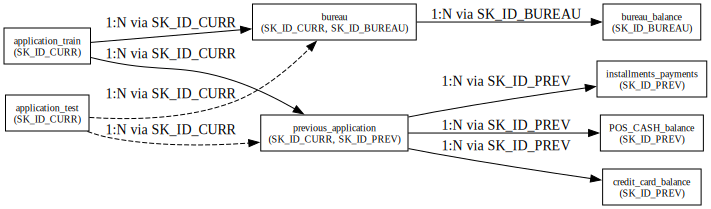

In [9]:
# ---------------------------------------------------------------
# Генерация диаграммы зависимостей между таблицами с помощью graphviz, чтобы визуально понять, как они связаны между собой (по каким ключам и в каком направлении)
# ---------------------------------------------------------------

from graphviz import Digraph

dot = Digraph('HomeCreditRelations')
dot.attr(rankdir='LR')
dot.attr('node', shape='box', fontsize='10')

dot.node('application_train', 'application_train\n(SK_ID_CURR)')
dot.node('application_test', 'application_test\n(SK_ID_CURR)')
dot.node('bureau', 'bureau\n(SK_ID_CURR, SK_ID_BUREAU)')
dot.node('bureau_balance', 'bureau_balance\n(SK_ID_BUREAU)')
dot.node('previous_application', 'previous_application\n(SK_ID_CURR, SK_ID_PREV)')
dot.node('installments_payments', 'installments_payments\n(SK_ID_PREV)')
dot.node('POS_CASH_balance', 'POS_CASH_balance\n(SK_ID_PREV)')
dot.node('credit_card_balance', 'credit_card_balance\n(SK_ID_PREV)')

dot.edge('application_train', 'bureau', label='1:N via SK_ID_CURR')
dot.edge('application_test', 'bureau', label='1:N via SK_ID_CURR', style='dashed')

dot.edge('bureau', 'bureau_balance', label='1:N via SK_ID_BUREAU')

dot.edge('application_train', 'previous_application', label='1:N via SK_ID_CURR')
dot.edge('application_test', 'previous_application', label='1:N via SK_ID_CURR', style='dashed')

dot.edge('previous_application', 'installments_payments', label='1:N via SK_ID_PREV')
dot.edge('previous_application', 'POS_CASH_balance', label='1:N via SK_ID_PREV')
dot.edge('previous_application', 'credit_card_balance', label='1:N via SK_ID_PREV')

# IMPORTANT: specify only the file prefix, not the extension
dot.render('reports/figures/relations_diagram', format='png', cleanup=True)

dot




In [10]:
# ---------------------------------------------------------------
# Создаем функцию для построения диаграммы структуры проекта на основе конфигурации, которая будет учитывать папки из "folders" и "stages", и позволит визуализировать структуру проекта в виде дерева. Это поможет лучше понять организацию файлов и папок в проекте.
# ---------------------------------------------------------------

def project_structure_diagram_builder(
        config_path="project_structure_config.json",
        output_path="reports/figures/project_structure_diagram_color",
        fmt="svg"
    ):
    """
    Строит диаграмму структуры проекта Graphviz, используя project_structure_config.json.

    - Использует только конфигурацию (без сканирования файловой системы)
    - Учитывает иерархию из "folders" и "stages"
    - Кроссплатформенно (Windows/Linux/macOS)
    - Избегает предупреждений о размере узлов, позволяя Graphviz автоматически определять размер узлов
    """

    # ---------------------------------------------------------
    # Загрузка конфигурации
    # ---------------------------------------------------------
    if not os.path.exists(config_path):
        raise FileNotFoundError(f"Файл конфигурации не найден: {config_path}")

    with open(config_path, "r", encoding="utf-8") as f:
        config = json.load(f)

    # Root name without trailing slash
    root_name = config["root"].replace("\\", "/").strip("/")

    # ---------------------------------------------------------
    # Вспомогательные функции
    # ---------------------------------------------------------
    def sanitize(rel_path: str) -> str:
        # Нормализует путь к прямым слешам и удаляет ведущие/концевые слеши
        return rel_path.replace("\\", "/").strip("/")

    def node_id(path: str) -> str:
        # Стабильный идентификатор узла из полного пути
        return sanitize(path).replace("/", "_")

    # ---------------------------------------------------------
    # Построение дерева папок из config["folders"] и config["stages"]
    # ---------------------------------------------------------
    tree = {}

    def add_path(rel_path: str):
        parts = sanitize(rel_path).split("/")
        cur = tree
        for p in parts:
            if not p:
                continue
            if p not in cur:
                cur[p] = {}
            cur = cur[p]

    # ---------------------------------------------------------------
    # Папки из "folders"
    # ---------------------------------------------------------------
    for rel in config["folders"].values():
        add_path(rel)

    # ---------------------------------------------------------------
    # Папки вывода этапов из "stages"
    # ---------------------------------------------------------------
    for stage in config["stages"].values():
        add_path(stage["output_path"])

    # ---------------------------------------------------------
    # Инициализация Graphviz
    # ---------------------------------------------------------
    structure = Digraph("ProjectStructure")

    # ---------------------------------------------------------------
    # Вводим аттрибуты для лучшего визуального представления
    # ---------------------------------------------------------------
    structure.attr(
        rankdir="TB",
        center="true",
        nodesep="0.8",
        ranksep="1.2"
    )

    structure.attr(
        "node",
        shape="box",
        style="filled,rounded",
        fontsize="18",
        fontname="Arial",
        margin="0.30,0.25"
    )

    COLOR_ROOT = "#4C72B0"
    COLOR_FOLDER = "#55A868"
    COLOR_SUBFOLDER = "#64B5CD"

    # ---------------------------------------------------------
    # Корневой узел
    # ---------------------------------------------------------
    root_path = root_name  # e.g. "Diploma_Project"
    root_nid = node_id(root_path)

    structure.node(root_nid, f"{root_name}/", fillcolor=COLOR_ROOT, fontcolor="white")
    structure.body.append("{ rank=source; " + root_nid + " }")

    # ---------------------------------------------------------
    # Рекурсивное построение
    # ---------------------------------------------------------
    def draw(full_path: str, subtree: dict, level: int = 0):
        parent_id = node_id(full_path)

        # Сортировка детей для стабильного расположения
        for name in sorted(subtree.keys()):
            child_path = f"{full_path}/{name}"
            nid = node_id(child_path)

            label = f"{name}/"
            color = COLOR_FOLDER if level == 0 else COLOR_SUBFOLDER

            structure.node(nid, label, fillcolor=color)
            structure.edge(parent_id, nid)

            draw(child_path, subtree[name], level + 1)

    # ---------------------------------------------------------------
    # Рисуем дерево под корнем
    # ---------------------------------------------------------------
    draw(root_path, tree, 0)

    # ---------------------------------------------------------------
    # Выравнивание папок верхнего уровня по горизонтали
    # ---------------------------------------------------------------
    top_level_ids = [node_id(f"{root_path}/{name}") for name in sorted(tree.keys())]
    if top_level_ids:
        structure.body.append("{ rank=same; " + " ".join(top_level_ids) + " }")

    # ---------------------------------------------------------
    # Экспорт диаграммы
    # ---------------------------------------------------------
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    structure.render(output_path, format=fmt, cleanup=True)

    print(f"✓ Диаграмма структуры проекта сгенерирована: {output_path}.{fmt}")

    return structure


✓ Диаграмма структуры проекта сгенерирована: reports/figures/project_structure_diagram_color.svg


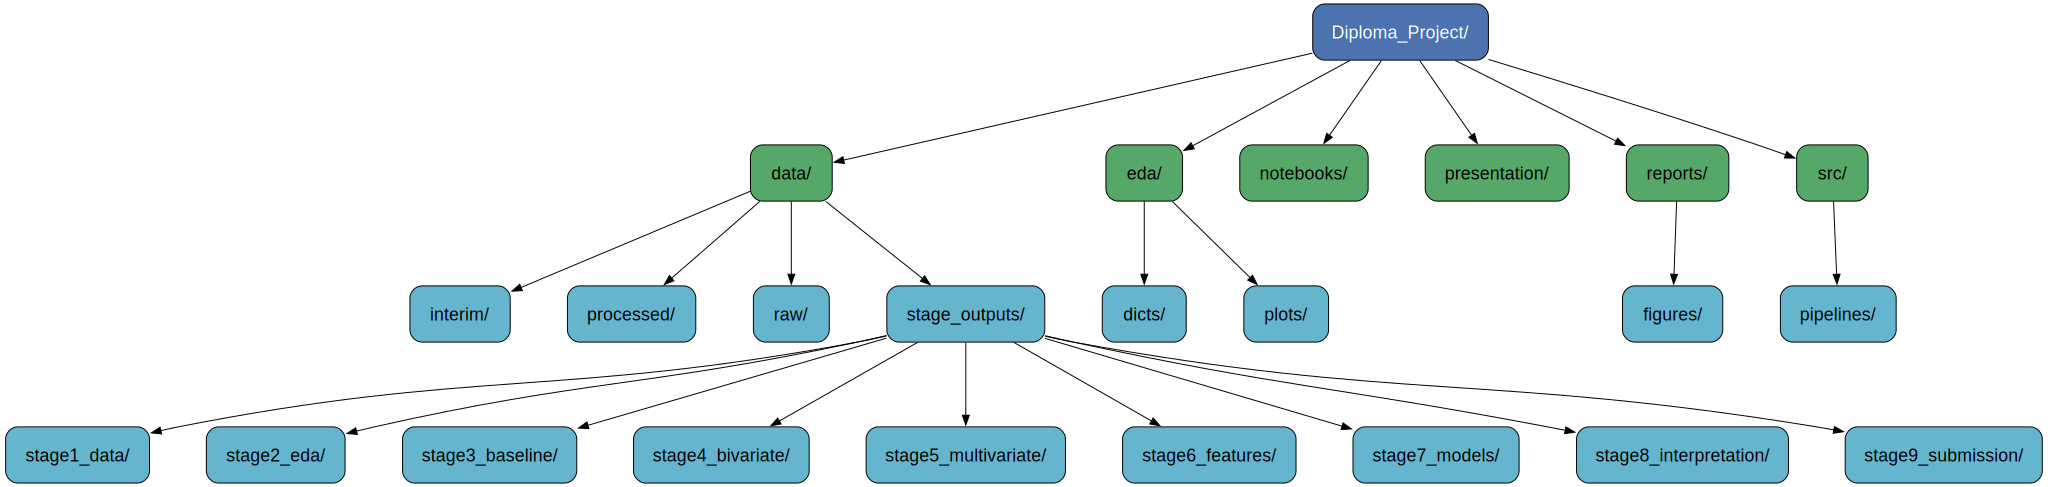

In [11]:
# ---------------------------------------------------------------
# Генерация диаграммы структуры проекта
# ---------------------------------------------------------------

project_structure_diagram_builder()


### Анализ целевой переменной TARGET

In [12]:
# ---------------------------------------------
# Анализ распределения целевой переменной TARGET
# ---------------------------------------------

# ---------------------------------------------------------------
# Получаем количество объектов каждого класса
# ---------------------------------------------------------------
target_counts = dfs['df_application_train']['TARGET'].value_counts()

# ---------------------------------------------------------------
# Получаем долю каждого класса в выборке
# ---------------------------------------------------------------
target_proportions = dfs['df_application_train']['TARGET'].value_counts(normalize=True)

print("Class counts:")
print(target_counts)

print("\nClass proportions:")
print(target_proportions)

Class counts:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Class proportions:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


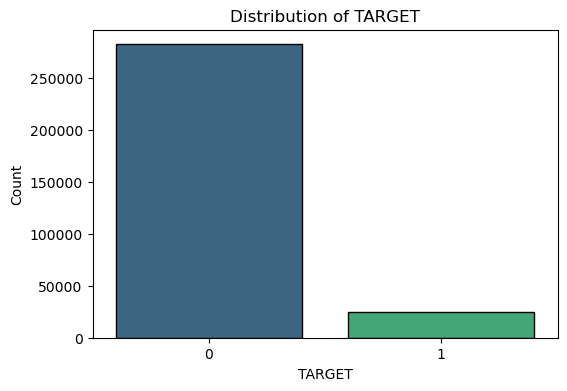

График сохранён: data/stage_outputs/stage1_data/target_distribution.png
Plot saved: data/stage_outputs/stage1_data/target_distribution.png


In [13]:
# ---------------------------------------------------------------
# Визуализация распределения классов TARGET и сохранение графика (динамический путь)
# ---------------------------------------------------------------

# ---------------------------------------------------------------
# Загружаем конфигурацию проекта
# ---------------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# ---------------------------------------------------------------
# Получаем путь Stage 1 из конфигурации
# ---------------------------------------------------------------
stage1_path = config["stages"]["stage1"]["output_path"]
os.makedirs(stage1_path, exist_ok=True)

plt.figure(figsize=(6,4))

# ---------------------------------------------------------------
# Столбчатая диаграмма распределения классов TARGET
# ---------------------------------------------------------------
sns.countplot(x='TARGET', data=dfs['df_application_train'], palette='viridis')

plt.title('Distribution of TARGET')
plt.xlabel('TARGET')
plt.ylabel('Count')

# ---------------------------------------------------------------
# Сохраняем график в Stage 1
# ---------------------------------------------------------------
plot_path = os.path.join(stage1_path, "target_distribution.png")
plt.savefig(plot_path, dpi=200, bbox_inches="tight")

plt.show()

print(f"График сохранён: {plot_path}")
print(f"Plot saved: {plot_path}")



In [14]:
# ---------------------------------------------
# Расчёт доли дефолтов (TARGET = 1)
# ---------------------------------------------

default_rate = dfs['df_application_train']['TARGET'].mean()

print(f"Default rate: {default_rate:.4f} ({default_rate*100:.2f}%)")


Default rate: 0.0807 (8.07%)


In [15]:
# ---------------------------------------------
# Автоматическое формирование первичных выводов
# ---------------------------------------------

total = len(dfs['df_application_train'])    # Общее число наблюдений
n0 = target_counts[0]                       # Количество класса 0
n1 = target_counts[1]                       # Количество класса 1
p1 = default_rate * 100                     # Процент дефолтов

print(f"""
Всего наблюдений: {total}
Класс 0 (нет дефолта): {n0} ({n0/total:.2%})
Класс 1 (дефолт): {n1} ({n1/total:.2%})

Доля дефолтов составляет {p1:.2f}%.

Первичные выводы:
- Целевая переменная несбалансирована (класс 1 встречается значительно реже).
- Модели могут склоняться к предсказанию класса 0.
- Может потребоваться обработка дисбаланса классов (class weights, oversampling, undersampling).
""")



Всего наблюдений: 307511
Класс 0 (нет дефолта): 282686 (91.93%)
Класс 1 (дефолт): 24825 (8.07%)

Доля дефолтов составляет 8.07%.

Первичные выводы:
- Целевая переменная несбалансирована (класс 1 встречается значительно реже).
- Модели могут склоняться к предсказанию класса 0.
- Может потребоваться обработка дисбаланса классов (class weights, oversampling, undersampling).



### Оценка качества данных

In [16]:
# ---------------------------------------------
# Унифицированная функция оценки качества данных
# ---------------------------------------------

def dqa_report(df, name):
    """
    df   : pandas DataFrame
    name : имя таблицы, например 'application_train'
    """
    print("=" * 80)
    print(f"Оценка качества данных для: {name}")
    print("=" * 80)

    # -------------------------
    # Пропуски
    # -------------------------
    missing_counts = df.isna().sum()
    missing_ratio = df.isna().mean()

    print("\n[Пропуски]")
    print("Топ 10 колонок по доле пропусков:")
    print(missing_ratio.sort_values(ascending=False).head(10))

    # -------------------------
    # Типы данных
    # -------------------------
    print("\n[Типы данных]")
    print(df.dtypes)

    # -------------------------
    # Выбросы (IQR)
    # -------------------------
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns

    def iqr_outliers(series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        lower = q1 - 1.5 * iqr
        upper = q3 + 1.5 * iqr
        return ((series < lower) | (series > upper)).sum()

    outlier_summary = {
        col: iqr_outliers(df[col].dropna())
        for col in numeric_cols
        if df[col].notna().sum() > 0
    }

    print("\n[Выбросы (IQR) - топ 10]")
    print(sorted(outlier_summary.items(), key=lambda x: x[1], reverse=True)[:10])

    # -------------------------
    # Категории 'XNA'
    # -------------------------
    categorical_cols = df.select_dtypes(include=['object']).columns

    print("\n['XNA' категории  ]")
    for col in categorical_cols:
        xna_count = (df[col] == 'XNA').sum()
        if xna_count > 0:
            print(f"{col}: {xna_count} вхождений 'XNA'")

    # -------------------------
    # Проблемы с временными признаками / Time feature issues
    # -------------------------
    days_cols = [col for col in df.columns if col.startswith('DAYS_')]

    print("\n[Проблемы с временными признаками (DAYS_*)]")
    for col in days_cols:
        pos_count = (df[col] > 0).sum()
        if pos_count > 0:
            print(f"{col}: {pos_count} положительных значений обнаружено (должны быть <= 0)")

    print("\nDQA завершена для:", name)
    print("=" * 80)


In [17]:
# ---------------------------------------------
# Пайплайн для автоматического запуска DQA
# ---------------------------------------------

for name, df in dfs.items():
    dqa_report(df, name)


Оценка качества данных для: df_application_train

[Пропуски]
Топ 10 колонок по доле пропусков:
COMMONAREA_AVG              0.698723
COMMONAREA_MODE             0.698723
COMMONAREA_MEDI             0.698723
NONLIVINGAPARTMENTS_MEDI    0.694330
NONLIVINGAPARTMENTS_MODE    0.694330
NONLIVINGAPARTMENTS_AVG     0.694330
FONDKAPREMONT_MODE          0.683862
LIVINGAPARTMENTS_AVG        0.683550
LIVINGAPARTMENTS_MEDI       0.683550
LIVINGAPARTMENTS_MODE       0.683550
dtype: float64

[Типы данных]
SK_ID_CURR                      int64
TARGET                          int64
NAME_CONTRACT_TYPE             object
CODE_GENDER                    object
FLAG_OWN_CAR                   object
                               ...   
AMT_REQ_CREDIT_BUREAU_DAY     float64
AMT_REQ_CREDIT_BUREAU_WEEK    float64
AMT_REQ_CREDIT_BUREAU_MON     float64
AMT_REQ_CREDIT_BUREAU_QRT     float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
Length: 122, dtype: object

[Выбросы (IQR) - топ 10]
[('REGION_RATING_CLIENT', np.int64

### 5. Оценка качества данных (Data Quality Assessment)

Для всех таблиц, участвующих в построении признаков и обучении модели, была проведена оценка качества данных (DQA) с использованием единой функции `dqa_report`. Анализ выполнялся для следующих таблиц:

- `df_application_train` — основная обучающая выборка.
- `df_application_test` — тестовая выборка без целевой переменной, проверяется на согласованность со структурой train.
- `df_bureau` — внешняя кредитная история клиентов.
- `df_bureau_balance` — помесячный статус кредитов из бюро.
- `df_previous_application` — история предыдущих заявок клиентов.
- `df_pos_cash_balance` — помесячные данные по POS и cash-кредитам.
- `df_installments_payments` — история платежей по кредитам.
- `df_credit_card_balance` — помесячные данные по кредитным картам.

Для каждой таблицы оценивались:

- **Пропуски**: количество и доля отсутствующих значений по столбцам.
- **Выбросы**: количество выбросов в числовых признаках по критерию IQR.
- **Аномалии**: некорректные значения (например, положительные значения в признаках `DAYS_*`, отрицательные суммы).
- **Неверные значения**: подозрительные или редкие категориальные значения.
- **Категории “XNA”**: использование `XNA` как маркера отсутствующих или неопределённых значений.
- **Проблемы с временными признаками**: проверка согласованности признаков `DAYS_*` (ожидаются неположительные значения).

Результаты DQA использовались для:
- выбора стратегий обработки пропусков,
- корректировки аномальных и неверных значений,
- принятия решений о включении/исключении признаков в модель,
- документирования ограничений и особенностей исходных данных.


## Заключение по рискам утечки целевой переменной (Target Leakage)  
### на основе результатов DQA всех таблиц Home Credit

В ходе комплексной оценки качества данных (DQA), проведённой для всех таблиц формата `df_*`, были выявлены систематические временные несоответствия и признаки использования будущей информации. Такие случаи представляют прямую угрозу **утечки целевой переменной (target leakage)**, поскольку модель может получить доступ к данным, которые недоступны на момент подачи заявки клиентом.

Ниже приведено структурированное заключение по каждой таблице.

---

### **1. `df_application_train` и `df_application_test`**

**Обнаруженные признаки утечки:**
- В столбце `DAYS_EMPLOYED` присутствуют **положительные значения**  
  - train: 55 374  
  - test: 9 274  
  Положительные значения означают события, произошедшие *после* даты подачи заявки, что невозможно и приводит к утечке будущей информации.

**Вывод:**  
Все положительные значения `DAYS_EMPLOYED` должны быть заменены на `NaN` или скорректированы.

---

### **2. `df_bureau`**

**Обнаруженные признаки утечки:**
- `DAYS_CREDIT_ENDDATE`: **602 603 положительных значений**  
  Указывает на дату окончания кредита *после* подачи заявки.
- `DAYS_CREDIT_UPDATE`: **17 положительных значений**  
  Обновления кредитной информации после даты заявки.

**Вывод:**  
Строки с положительными `DAYS_*` содержат будущие события и должны быть удалены или скорректированы.

---

### **3. `df_bureau_balance`**

**Обнаруженные признаки утечки:**  
- Не выявлено. Все значения `MONTHS_BALANCE` корректны (≤ 0).

**Вывод:**  
Риск утечки отсутствует.

---

### **4. `df_previous_application`**

**Обнаруженные признаки утечки:**  
Массовые положительные значения временных признаков:

- `DAYS_FIRST_DRAWING`: 934 444  
- `DAYS_FIRST_DUE`: 40 645  
- `DAYS_LAST_DUE_1ST_VERSION`: 318 256  
- `DAYS_LAST_DUE`: 211 221  
- `DAYS_TERMINATION`: 225 913  

Все эти значения описывают события, произошедшие *после* текущей заявки.

**Вывод:**  
Все положительные `DAYS_*` должны быть исключены или заменены на `NaN`.

---

### **5. `df_POS_CASH_balance`**

**Обнаруженные признаки утечки:**  
- Не выявлено. `MONTHS_BALANCE` всегда ≤ 0.

**Вывод:**  
Риск утечки отсутствует.

---

### **6. `df_installments_payments`**

**Обнаруженные признаки утечки:**
- `DAYS_ENTRY_PAYMENT`: 1 положительное значение  
  Это означает платёж, зарегистрированный после даты заявки.

**Вывод:**  
Строка должна быть удалена или скорректирована.

---

### **7. `df_credit_card_balance`**

**Обнаруженные признаки утечки:**  
- Не выявлено. Все временные признаки корректны.

**Вывод:**  
Риск утечки отсутствует.

---

## Итоговое заключение

Основным источником утечки целевой переменной в датасете Home Credit являются **временные признаки (`DAYS_*`, `MONTHS_BALANCE`)**, содержащие **положительные значения**, которые отражают события, произошедшие *после* подачи заявки. Использование таких данных при обучении приводит к завышенной оценке качества модели и ухудшению её обобщающей способности.

### Таблицы с подтверждёнными рисками утечки:
- `df_application_train`  
- `df_application_test`  
- `df_bureau`  
- `df_previous_application`  
- `df_installments_payments` (единичные случаи)

### Таблицы без рисков утечки:
- `df_bureau_balance`  
- `df_POS_CASH_balance`  
- `df_credit_card_balance`

### Рекомендуемые меры:
- Заменить все положительные значения `DAYS_*` на `NaN` или удалить соответствующие строки.  
- Проверить согласованность временных признаков после очистки.  
- Документировать все корректировки в разделе предобработки данных дипломной работы.

---


## Унифицированная функция очистки данных (Data Cleaning Function)

Для обеспечения воспроизводимости и единообразия предобработки данных была разработана
унифицированная функция очистки, применяемая ко всем таблицам набора Home Credit.
Функция выполняет следующие ключевые операции:

### 1. Замена категориального значения `'XNA'` на пропуски (`NaN`)
Во всех таблицах встречается специальное значение `'XNA'`, обозначающее отсутствие информации.
Для корректной обработки категориальных признаков оно заменяется на `NaN`.

### 2. Устранение утечек целевой переменной (Target Leakage)
Все положительные значения временных признаков `DAYS_*` и `MONTHS_BALANCE` заменяются на `NaN`,
поскольку такие значения отражают события, произошедшие *после* даты подачи заявки, и могут привести
к утечке будущей информации в модель.

### 3. Коррекция placeholder‑значений
Некоторые признаки содержат специальные технические значения, которые не являются реальными.
Наиболее важный пример:

- `DAYS_EMPLOYED = 365243` — это не реальный стаж, а код, обозначающий отсутствие данных.

Такое значение необходимо заменить на `NaN`, поскольку:

- оно искажает статистику и визуализацию,
- нарушает распределение признака,
- может привести к утечке целевой переменной (положительное значение временного признака),
- мешает корректной работе алгоритмов машинного обучения.

### 4. Нормализация типов данных
Категориальные признаки приводятся к типу `category`, числовые — к корректным числовым типам.
Это обеспечивает согласованность данных и оптимизирует использование памяти.

### 5. Единообразие обработки всех таблиц
Использование единой функции позволяет:

- автоматизировать подготовку данных,
- уменьшить количество ошибок,
- обеспечить одинаковую логику очистки для всех таблиц,
- гарантировать корректность последующего EDA и построения признаков.

---

Такой подход делает процесс предобработки данных масштабируемым, прозрачным и полностью
воспроизводимым, что является обязательным требованием для качественного анализа и построения
надёжной модели кредитного скоринга.



In [18]:
# ---------------------------------------------------------
# Унифицированная функция очистки таблиц Home Credit
# ---------------------------------------------------------

def clean_home_credit_table(df, name):
    """
    df   : pandas DataFrame
    name : имя таблицы, например 'application_train'
    """

    df = df.copy()

    # ---------------------------------------------
    # 1. Замена 'XNA' на NaN
    # ---------------------------------------------
    df = df.replace('XNA', np.nan)

    # ---------------------------------------------
    # 2. Очистка временных признаков DAYS_*
    # ---------------------------------------------
    days_cols = [col for col in df.columns if col.startswith('DAYS_')]
    for col in days_cols:
        # Положительные значения → NaN (утечка будущего)
        df.loc[df[col] > 0, col] = np.nan

    # ---------------------------------------------
    # 3. Очистка MONTHS_BALANCE (если есть)
    # ---------------------------------------------
    if 'MONTHS_BALANCE' in df.columns:
        df.loc[df['MONTHS_BALANCE'] > 0, 'MONTHS_BALANCE'] = np.nan

    # ---------------------------------------------
    # 4. Специальные placeholder‑значения
    # ---------------------------------------------
    if 'DAYS_EMPLOYED' in df.columns:
        df.loc[df['DAYS_EMPLOYED'] == 365243, 'DAYS_EMPLOYED'] = np.nan

    # ---------------------------------------------
    # 5A. Преобразование возраста в годы (для удобства)
    # ---------------------------------------------
    if 'DAYS_BIRTH' in df.columns:
        df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).astype('float')

    # ---------------------------------------------
    # 5B. Удаление невозможных отрицательных значений
    # ---------------------------------------------
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    # Значения < 0 → NaN (кроме временных признаков DAYS_*)
    for col in num_cols:
        if not col.startswith('DAYS_'):
            df.loc[df[col] < 0, col] = np.nan

    # ---------------------------------------------
    # 6. Приведение типов (если требуется)
    # ---------------------------------------------
    for col in df.select_dtypes(include=['object']).columns:
        df[col] = df[col].astype('category')

    return df



In [19]:
# ---------------------------------------------------------
# Пайплайн очистки всех таблиц df_*, используя функцию clean_home_credit_table(), и сохранение очищенных DataFrame в новый словарь dfs_cleaned для дальнейшего использования в EDA и моделировании.
# ---------------------------------------------------------

# ---------------------------------------------
# Словарь для хранения очищенных DataFrame
# ---------------------------------------------
dfs_cleaned = {}

for name, df in dfs.items():
    dfs_cleaned[name] = clean_home_credit_table(df, name)
    print(f"Очистка завершена: {name}")


Очистка завершена: df_application_train
Очистка завершена: df_bureau
Очистка завершена: df_bureau_balance
Очистка завершена: df_credit_card_balance
Очистка завершена: df_installments_payments
Очистка завершена: df_pos_cash_balance
Очистка завершена: df_previous_application


In [20]:
# ---------------------------------------------------------
# Сохраняем очищенные таблицы Stage 1, используя путь из конфигурации проекта
# ---------------------------------------------------------

# ---------------------------------------------------------
# Загружаем конфигурацию проекта
# ---------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

# Получаем путь Stage 1 из конфигурации
# Getting Stage 1 output path from config
stage1_path = config["stages"]["stage1"]["output_path"]
os.makedirs(stage1_path, exist_ok=True)

# Сохраняем каждую очищенную таблицу отдельно
# Saving each cleaned table individually
for name, df in dfs_cleaned.items():
    file_path = os.path.join(stage1_path, f"cleaned_{name}.pkl")
    with open(file_path, "wb") as f:
        pickle.dump(df, f)
    print(f"Saved: {file_path}")



Saved: data/stage_outputs/stage1_data/cleaned_df_application_train.pkl
Saved: data/stage_outputs/stage1_data/cleaned_df_bureau.pkl
Saved: data/stage_outputs/stage1_data/cleaned_df_bureau_balance.pkl
Saved: data/stage_outputs/stage1_data/cleaned_df_credit_card_balance.pkl
Saved: data/stage_outputs/stage1_data/cleaned_df_installments_payments.pkl
Saved: data/stage_outputs/stage1_data/cleaned_df_pos_cash_balance.pkl
Saved: data/stage_outputs/stage1_data/cleaned_df_previous_application.pkl


## Функция `dataset_reduction()`: назначение и применение

### Назначение
Функция `dataset_reduction()` уменьшает размер каждого датафрейма в словаре `dfs_cleaned`, выбирая случайную долю строк (`sample_frac`).  
Это позволяет значительно ускорить дальнейшие этапы анализа данных (EDA), построение словарей, вычисление статистик и генерацию графиков.
Использование этой функции на этапе разработки обучающейся модели позволит сэкономить существенное время. По окончанию процесса разработки
модель будет обучена на полном наборе данных (sample_frac-1.0)

### Когда использовать
Используйте `dataset_reduction()` **после очистки данных**, но **до запуска EDA‑пайплайна**, если:
- исходные таблицы слишком большие (миллионы строк);
- полный EDA занимает слишком много времени;
- вы хотите быстро протестировать логику пайплайна;
- вы работаете в ограниченной среде (ограничения по памяти/CPU).

### Как работает
Для каждой таблицы в `dfs_cleaned` функция:
1. случайным образом выбирает `sample_frac` долю строк;
2. возвращает новый словарь с уменьшенными таблицами;
3. сохраняет структуру словаря (ключи не меняются);
4. обеспечивает воспроизводимость через `random_state`.

### Пример использования
```python
dfs_cleaned = dataset_reduction(dfs_cleaned, sample_frac=0.1)
run_full_eda(dfs_cleaned, eda_config)


In [21]:
def dataset_reduction(dfs_cleaned, sample_frac=1.0, random_state=42):
    """
    Уменьшает размер каждого датафрейма в dfs_cleaned,
    выбирая случайную долю строк (sample_frac).
    
    Параметры:
        dfs_cleaned: словарь датафреймов, например:
                     {"df_application_train": df, ...}
        sample_frac: доля строк для выборки (1.0 = полный размер)
        random_state: seed для воспроизводимости

    Возвращает:
        reduced_dfs: словарь уменьшенных датафреймов
    """

    reduced_dfs = {}

    for name, df in dfs_cleaned.items():
        print(f"Снижаю размер таблицы: {name}")

        if sample_frac < 1.0:
            df_reduced = df.sample(
                frac=sample_frac,
                random_state=random_state
            ).reset_index(drop=True)
            print(f"  → {len(df_reduced)} строк ({sample_frac*100:.1f}% выборки)")
        else:
            df_reduced = df.copy()
            print(f"  → полный размер: {len(df_reduced)} строк")

        reduced_dfs[name] = df_reduced

    print("Уменьшение датасета завершено.")
    return reduced_dfs


# Stage 2 — Univariate EDA и отбор перспективных признаков (`stage2_eda`)

**Назначение этапа:**  
Провести детальный одномерный анализ признаков (Univariate EDA),  
оценить качество данных, вычислить статистики и флаги качества,  
выделить шумовые признаки и сформировать список перспективных признаков  
для последующих этапов моделирования.

**Входные данные:**  
- Очищенные таблицы из Stage 1 (`dfs_cleaned`)  
- **Путь к данным:** `data/stage_outputs/stage1_data/`

**Выходные данные:**  
- Словари EDA:  
  - `summary_dict`  
  - `numeric_stats_dict`  
  - `categorical_stats_dict`  
  - `quality_flags_dict`  
  - `correlation_dict`  
  - `plot_recommendations_dict`  
  - `table_specific_dict`  
- Отчёт о качестве данных (DQA summary)  
- Список перспективных признаков (`promising_features`)  
- Отчёт об удалённых признаках (`removal_report`)  
- Графики только для перспективных признаков  
- Итоговый отчёт Stage 2 (`stage2_summary.json`)  
- **Путь сохранения:** `data/stage_outputs/stage2_eda/`

**Краткое описание обработки:**  
- Загрузка очищенных таблиц Stage 1  
- Применение конфигурации EDA (`eda_config`)  
- Построение EDA‑словарей (статистики, флаги качества, корреляции, рекомендации)  
- Агрегация результатов DQA  
- Фильтрация шумовых признаков и формирование списка перспективных  
- Сохранение словарей, отчётов и списков признаков  
- Генерация графиков только для перспективных признаков  
- Формирование итогового отчёта Stage 2  
- Подготовка набора данных для Stage 3 (модельная таблица с перспективными признаками)


In [22]:
# ---------------------------------------------------------
# Загрузка очищенных таблиц Stage 1 + опциональное уменьшение датасета
# ---------------------------------------------------------

def data_loading_stage1_to_2(dfs_cleaned, sample_frac=1.0, random_state=42):
    """
    Загружает очищенные таблицы Stage 1, если dfs_cleaned пуст.
    При необходимости уменьшает размер таблиц с помощью sample_frac.
        Параметры:
            dfs_cleaned: словарь с очищенными DataFrame (может быть пустым)
            sample_frac: доля строк для загрузки (1.0 = полный размер)
            random_state: seed для воспроизводимости
        Возвращает:
            dfs_cleaned_loaded: словарь с загруженными (и возможно уменьшенными) DataFrame для Stage 2 EDA
    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    stage1_path = config["stages"]["stage1"]["output_path"]

    # ---------------------------------------------------------
    # Если dfs_cleaned уже заполнен — просто возвращаем его
    # ---------------------------------------------------------
    if dfs_cleaned:
        print("✔ dfs_cleaned уже загружен в память — используя существующие данные.")
        # Если нужно уменьшить — уменьшаем
        if sample_frac < 1.0:
            print(f"Применение уменьшения датасета: sample_frac={sample_frac}")
            dfs_cleaned = dataset_reduction(dfs_cleaned, sample_frac, random_state)
        return dfs_cleaned

    # ---------------------------------------------------------
    # Иначе загружаем очищенные таблицы из Stage 1
    # ---------------------------------------------------------
    print(f"Загрузка очищенных таблиц из: {stage1_path}")

    if not os.path.exists(stage1_path):
        raise FileNotFoundError(f"Папка с результатами Stage 1 не найдена: {stage1_path}")

    dfs_cleaned_loaded = {}

    for file in os.listdir(stage1_path):
        if file.startswith("cleaned_") and file.endswith(".pkl"):
            table_name = file.replace("cleaned_", "").replace(".pkl", "")
            file_path = os.path.join(stage1_path, file)

            with open(file_path, "rb") as f:
                df = pickle.load(f)

            dfs_cleaned_loaded[table_name] = df
            print(f"   ✔ Загружено: {file}  → shape={df.shape}")

    if not dfs_cleaned_loaded:
        raise RuntimeError("Не найдено очищенных таблиц в папке с результатами Stage 1.")

    print(f"\n✔ Загружено {len(dfs_cleaned_loaded)} очищенных таблиц из Stage 1.")

    # ---------------------------------------------------------
    # Применяем уменьшение датасета, если требуется
    # ---------------------------------------------------------
    if sample_frac < 1.0:
        print(f"\nПрименение уменьшения датасета: sample_frac={sample_frac}")
        dfs_cleaned_loaded = dataset_reduction(
            dfs_cleaned_loaded,
            sample_frac=sample_frac,
            random_state=random_state
        )

    return dfs_cleaned_loaded



In [23]:
# ---------------------------------------------------------
# Инициализация Stage 2
# ---------------------------------------------------------

print("\n=== Инициализация Stage 2: EDA ===")
# ---------------------------------------------------------
# Загрузка очищенных таблиц Stage 1
# ---------------------------------------------------------
dfs_cleaned = data_loading_stage1_to_2(dfs_cleaned={}, sample_frac=1.0)




=== Инициализация Stage 2: EDA ===
Загрузка очищенных таблиц из: data/stage_outputs/stage1_data/
   ✔ Загружено: cleaned_df_application_train.pkl  → shape=(307511, 123)
   ✔ Загружено: cleaned_df_bureau.pkl  → shape=(1716428, 17)
   ✔ Загружено: cleaned_df_bureau_balance.pkl  → shape=(27299925, 3)
   ✔ Загружено: cleaned_df_credit_card_balance.pkl  → shape=(3840312, 23)
   ✔ Загружено: cleaned_df_installments_payments.pkl  → shape=(13605401, 8)
   ✔ Загружено: cleaned_df_pos_cash_balance.pkl  → shape=(10001358, 8)
   ✔ Загружено: cleaned_df_previous_application.pkl  → shape=(1670214, 37)

✔ Загружено 7 очищенных таблиц из Stage 1.


После выполнения унифицированной функции очистки все таблицы набора Home Credit приведены к корректному состоянию для проведения разведочного анализа данных (EDA).

Функция устранила утечки целевой переменной, заменила placeholder‑значения, нормализовала типы данных и привела отсутствующие значения к единому формату.

# Архитектура EDA в многотабличном проекте Home Credit

Проект Home Credit состоит из нескольких связанных таблиц, каждая из которых имеет собственные типы данных, пропуски, кардинальность признаков и предметные особенности.  
Классический подход «делать EDA по одной таблице» приводит к перегрузке выводом, разрозненности результатов и невозможности повторно использовать вычисленные статистики.

Чтобы обеспечить модульность, управляемость и воспроизводимость анализа, EDA организован в виде **тематических словарей**, каждый из которых отвечает за свою область анализа.  
Такой подход делает EDA:
- **модульным** — каждая тема изолирована;  
- **масштабируемым** — легко добавлять новые метрики;  
- **воспроизводимым** — поведение управляется конфигурацией;  
- **управляемым** — вывод не перегружен;  
- **практичным** — результаты используются на следующих этапах (feature engineering, отчёты).

---

## Тематические словари EDA: структура и назначение

### **1. `summary_dict` — сводная информация по таблицам**
Содержит:
- размер таблицы;  
- типы данных;  
- количество уникальных значений;  
- долю пропусков;  
- долю нулевых и отрицательных значений.  

**Назначение:** быстрое понимание структуры таблицы.

---

### **2. `numeric_stats_dict` — статистика числовых признаков**
Содержит:
- описательные статистики;  
- квантили (1%, 5%, 95%, 99%);  
- дисперсию;  
- skewness и kurtosis;  
- IQR и количество выбросов.  

**Назначение:** выявление выбросов, перекосов распределений и аномалий.

---

### **3. `categorical_stats_dict` — статистика категориальных признаков**
Содержит:
- кардинальность;  
- топ‑категории;  
- редкие категории (<1%);  
- моду.  

**Назначение:** подготовка к кодированию категорий и выявление проблемных признаков.

---

### **4. `quality_flags_dict` — флаги качества данных**
Содержит:
- признаки с высокой долей пропусков;  
- константные признаки;  
- признаки с высокой кардинальностью.  

**Назначение:** выявление признаков, требующих очистки или удаления.

---

### **5. `correlation_dict` — корреляции и зависимости**
Содержит:
- корреляцию Пирсона;  
- корреляцию Спирмена.  

**Назначение:** отбор признаков и анализ избыточности.

---

### **6. `plot_recommendations_dict` — рекомендации по визуализации**
Содержит:
- рекомендуемые числовые и категориальные признаки;  
- признаки с высокой асимметрией;  
- признаки с высокой долей пропусков;  
- признаки с высокой кардинальностью.  

**Назначение:** избежать перегрузки графиками и сосредоточиться на ключевых признаках.

---

### **7. `table_specific_dict` — предметно‑ориентированные метрики**
Содержит:
- метрики, специфичные для каждой таблицы (например, задержки платежей, активные кредиты, коэффициенты использования кредитных карт).  

**Назначение:** учёт особенностей предметной области кредитного скоринга.

---

## Конфигурационный словарь `eda_config` как единая точка управления

Все параметры EDA объединены в единый конфигурационный словарь `eda_config`, который определяет:
- какие таблицы анализировать;  
- какие фильтры строк и столбцов применять;  
- какие пороги использовать;  
- какие вычисления включать или отключать;  
- какие предметные метрики считать.  

Это позволяет менять поведение EDA **без изменения кода**, просто подставляя другую конфигурацию.

---

## Преимущества архитектуры тематических словарей

- **Модульность** — каждая тема изолирована.  
- **Масштабируемость** — легко добавлять новые метрики.  
- **Повторное использование** — словари применяются в feature engineering и отчётности.  
- **Контроль производительности** — тяжёлые вычисления можно отключать.  
- **Чистота ноутбука** — вывод не перегружен.  
- **Воспроизводимость** — конфигурации можно сохранять и повторно использовать.  

Архитектура тематических словарей создаёт прочный фундамент для профессионального EDA в многотабличных проектах.


In [24]:
# ---------------------------------------------------------
# Конфигурация для EDA и DQA (без жёстких путей)
# Configuration for EDA and DQA (no rigid paths)
# ---------------------------------------------------------

eda_config = {

    # -----------------------------------------------------
    # 1. Какие таблицы анализировать
    # -----------------------------------------------------
    "tables": None,  # None = все таблицы

    # -----------------------------------------------------
    # 2. Фильтры строк
    # -----------------------------------------------------
    "row_filters": {
        # "bureau": lambda df: df[df["CREDIT_ACTIVE"] == "Active"],
    },

    # -----------------------------------------------------
    # 3. Фильтры столбцов
    # -----------------------------------------------------
    "column_filters": {
        # "application_train": lambda cols: [c for c in cols if "AMT" in c],
    },

    # -----------------------------------------------------
    # 4. Пороги качества данных
    # -----------------------------------------------------
    "missing_threshold": 0.5,
    "cardinality_threshold": 100,
    "skew_threshold": 1.0,

    # -----------------------------------------------------
    # 5. Пределы визуализаций
    # -----------------------------------------------------
    "max_numeric_plots": 10,
    "max_categorical_plots": 10,

    # -----------------------------------------------------
    # 6. Тяжелые вычисления
    # -----------------------------------------------------
    "compute_correlations": True,
    "compute_mutual_info": False,

    # -----------------------------------------------------
    # 7. Табличные параметры
    # -----------------------------------------------------
    "table_specific_params": {
        "bureau": {"compute_active_credit_stats": True},
        "installments_payments": {"compute_delay_stats": True},
        "credit_card_balance": {"compute_utilization": True},
    },

    # -----------------------------------------------------
    # 8. Пути кеширования
    # -----------------------------------------------------
    # Пути берутся ТОЛЬКО из project_structure_config.json
}



In [25]:
# ---------------------------------------------------------
# Инициализация словарей для хранения результатов EDA
# ---------------------------------------------------------

summary_dict = {}
numeric_stats_dict = {}
categorical_stats_dict = {}
quality_flags_dict = {}
correlation_dict = {}
plot_recommendations_dict = {}
table_specific_dict = {}


## Creating Summary Dictionary: Summary — базовая информация о таблице
Этот блок собирает ключевые структурные характеристики таблицы: размер, типы данных, уникальные значения, пропуски, нули и отрицательные значения.


In [26]:
# ---------------------------------------------------------
# Унифицированная функция для построения сводного словаря с базовой информацией о каждой таблице, который будет использоваться в дальнейшем для анализа и принятия решений по обработке данных
# ---------------------------------------------------------

def build_summary_dict(df):
    return {
        "shape": df.shape,
        "dtypes": df.dtypes,
        "n_unique": df.nunique(),
        "missing_fraction": df.isna().mean(),
        "zero_fraction": (df == 0).mean(numeric_only=True),
        "negative_fraction": (df.select_dtypes(include=["float64", "int64"]) < 0).mean()
    }


## Creating Numeric Dictionary: Numeric Stats — статистика числовых признаков
Содержит описательные статистики, квантили, асимметрию, эксцесс, дисперсию, IQR и количество выбросов.


In [27]:
# ---------------------------------------------------------
# Расширенная версия build_numeric_dict с дополнительными метриками по каждой числовой колонке
# ---------------------------------------------------------

def build_numeric_dict(df, skew_threshold):
    num_cols = df.select_dtypes(include=["float64", "int64"]).columns
    if len(num_cols) == 0:
        return {}

    numeric_dict = {}

    for col in num_cols:
        series = df[col].dropna()

        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1

        outlier_mask = (series < (q1 - 1.5 * iqr)) | (series > (q3 + 1.5 * iqr))
        outlier_count = int(outlier_mask.sum())

        numeric_dict[col] = {
            "mean": float(series.mean()),
            "std": float(series.std()),
            "skew": float(series.skew()),
            "kurt": float(series.kurtosis()),
            "iqr": float(iqr),
            "outliers": outlier_count,
            "is_skewed": abs(series.skew()) > skew_threshold
        }

    return numeric_dict


## Creating Categorical Dictionary: Categorical Stats — статистика категориальных признаков
Содержит кардинальность, топ‑категории, редкие категории и моду.


In [28]:
# ---------------------------------------------------------
# Расширенная версия build_categorical_dict с дополнительными метриками по каждой категорической колонке
# ---------------------------------------------------------

def build_categorical_dict(df):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    stats = {}

    for col in cat_cols:
        series = df[col].dropna()

        # Value counts
        vc = series.value_counts()
        freq = vc / len(series)

        # Top category
        if not vc.empty:
            top_value = vc.idxmax()
            top_freq = float(freq.max())
        else:
            top_value = None
            top_freq = 0.0

        stats[col] = {
            "n_unique": int(series.nunique()),
            "top_value": top_value,
            "top_freq": top_freq,
            "rare_categories": vc[freq < 0.01].to_dict(),   # преобразовать в словарь для сериализации
            "top_categories": vc.head(10).to_dict(),        # преобразовать в словарь для сериализации
            "mode": series.mode().iloc[0] if not series.mode().empty else None
        }

    return stats



## Creating Quality Dictionary: Quality Flags — флаги качества данных
Определяет признаки с высокой долей пропусков, константные признаки и признаки с высокой кардинальностью.


In [29]:
# ---------------------------------------------------------
# Расширенная версия build_quality_dict, которая использует результаты из summary_dict и добавляет флаги качества данных на основе заданных порогов для пропусков, кардинальности, и других метрик, чтобы автоматически выявлять потенциальные проблемы с данными в каждой таблице.
# ---------------------------------------------------------

def build_quality_dict(df, summary, cardinality_threshold, missing_threshold):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    high_missing = summary["missing_fraction"][summary["missing_fraction"] > missing_threshold].index.tolist()
    constant_features = [col for col in df.columns if df[col].nunique(dropna=False) <= 1]
    high_cardinality = [col for col in cat_cols if df[col].nunique() > cardinality_threshold]

    return {
        "high_missing_features": high_missing,
        "constant_features": constant_features,
        "high_cardinality_features": high_cardinality
    }


## Creating Correlation Dictionary: Correlations — корреляции числовых признаков
Вычисляет корреляции Пирсона и Спирмена (если включено в конфигурации).


In [30]:
# ---------------------------------------------------------
# Функция для построения словаря с корреляциями между числовыми признаками, которая будет использоваться для выявления сильных линейных и монотонических зависимостей между признаками, что может помочь в дальнейшем при выборе признаков для моделирования и при обработке мультиколлинеарности.
# ---------------------------------------------------------

def build_correlation_dict(df, compute_correlations):
    num_cols = df.select_dtypes(include=["float64", "int64"]).columns
    if not compute_correlations or len(num_cols) == 0:
        return {}

    return {
        "pearson": df[num_cols].corr(method="pearson"),
        "spearman": df[num_cols].corr(method="spearman")
    }


## Creating Plot Recommendations Dictionary: Plot Recommendations — рекомендации по визуализации
Выбирает ограниченное число признаков для графиков, чтобы не перегружать вывод.


In [31]:
# ---------------------------------------------------------
# Функция для построения словаря с рекомендациями по визуализации, которая будет использоваться для автоматической генерации графиков распределения и категориальных диаграмм для наиболее важных признаков, а также для выявления признаков с сильной асимметрией или большим количеством пропусков, которые могут потребовать специального внимания при визуализации.
# ---------------------------------------------------------

def build_plot_recommendations_dict(df, numeric_stats, quality_flags, max_numeric, max_categorical):
    num_cols = df.select_dtypes(include=["float64", "int64"]).columns
    cat_cols = df.select_dtypes(include=["object", "category"]).columns

    return {
        "recommended_numeric": list(num_cols[:max_numeric]),
        "recommended_categorical": list(cat_cols[:max_categorical]),
        "skewed_features": numeric_stats.get("skewed_features", []),
        "heavy_missing_features": quality_flags["high_missing_features"],
        "high_cardinality_features": quality_flags["high_cardinality_features"]
    }


## Creating Tables Specific Dictionary: Table‑Specific Metrics — предметно‑ориентированные метрики
Добавляет метрики, специфичные для отдельных таблиц (например, задержки платежей, активные кредиты).


In [32]:
# ---------------------------------------------------------
# Функция для построения словаря с метриками, специфичными для каждой таблицы, которая будет использоваться для вычисления специализированных метрик, таких как количество активных кредитов в таблице bureau, средняя задержка платежей в installments_payments, или средняя загрузка кредитной линии в credit_card_balance, что может помочь в дальнейшем при анализе данных и при выборе признаков для моделирования.
# ---------------------------------------------------------

def build_table_specific_dict(df, table_name, params):
    metrics = {}

    if table_name == "bureau" and params.get("compute_active_credit_stats"):
        metrics["active_credits"] = (df["CREDIT_ACTIVE"] == "Active").sum()

    if table_name == "installments_payments" and params.get("compute_delay_stats"):
        if "DAYS_INSTALMENT" in df and "DAYS_ENTRY_PAYMENT" in df:
            metrics["avg_payment_delay"] = (df["DAYS_ENTRY_PAYMENT"] - df["DAYS_INSTALMENT"]).mean()

    if table_name == "credit_card_balance" and params.get("compute_utilization"):
        if "AMT_BALANCE" in df and "AMT_CREDIT_LIMIT_ACTUAL" in df:
            metrics["avg_utilization"] = (df["AMT_BALANCE"] / df["AMT_CREDIT_LIMIT_ACTUAL"]).mean()

    return metrics


## Оркестратор: build_eda_dictionaries
Вызывает все блоки по очереди и заполняет тематические словари.


In [33]:
# ---------------------------------------------------------
# Унифицированная функция для построения всех EDA словарей для каждой таблицы, которая будет использоваться для последовательного анализа каждой таблицы в dfs_cleaned с применением заданных фильтров и порогов из eda_config, и сохранения результатов в соответствующих словарях для дальнейшего использования в анализе данных и при принятии решений по обработке данных.
# ---------------------------------------------------------

def build_eda_dictionaries(dfs_cleaned, eda_config):

    # Выбор правильной таблицы
    tables = eda_config.get("tables")
    if not tables:   # catches None, [], {}, empty tuple
        tables = dfs_cleaned.keys()

    for name in tables:
        df = dfs_cleaned[name]

        # Фильтры строк
        if name in eda_config.get("row_filters", {}):
            df = eda_config["row_filters"][name](df)

        # Фильтры столбцов
        if name in eda_config.get("column_filters", {}):
            cols = eda_config["column_filters"][name](df.columns)
            df = df[cols]

        # Построение сводной информации
        summary = build_summary_dict(df)
        summary_dict[name] = summary

        # Числовые показатели
        numeric_stats = build_numeric_dict(df, eda_config["skew_threshold"])
        numeric_stats_dict[name] = numeric_stats

        # Категориальные показатели
        categorical_stats = build_categorical_dict(df)
        categorical_stats_dict[name] = categorical_stats

        # Качество данных
        quality_flags = build_quality_dict(
            df, summary,
            eda_config["cardinality_threshold"],
            eda_config["missing_threshold"]
        )
        quality_flags_dict[name] = quality_flags

        # Корреляции
        correlation_dict[name] = build_correlation_dict(
            df, eda_config["compute_correlations"]
        )

        # Рекомендации по визуализации
        plot_recommendations_dict[name] = build_plot_recommendations_dict(
            df, numeric_stats, quality_flags,
            eda_config["max_numeric_plots"],
            eda_config["max_categorical_plots"]
        )

        # Специфические метрики для таблицы
        table_specific_dict[name] = build_table_specific_dict(
            df, name,
            eda_config.get("table_specific_params", {}).get(name, {})
        )

    print("EDA словари успешно построены.")



# Создаем набор Plotting Functions

`plot_numeric_distribution()`

Показывает распределение числового признака (гистограмма + KDE).  
Используется для быстрого выявления выбросов, асимметрии и формы распределения.

`plot_categorical_frequency()`

Строит bar‑chart по топ‑категориям.  
Помогает увидеть частоты, редкие категории и оценить кардинальность признака.

`plot_recommended_for_table()`

Автоматически строит только те графики, которые рекомендованы EDA (из `plot_recommendations_dict`).  
Позволяет избежать перегрузки визуализациями и сосредоточиться на ключевых признаках.


## Модуль кеширования EDA

Кеширование включает:
- сохранение всех словарей EDA;
- загрузку словарей при старте ноутбука;
- кеширование графиков;
- автоматическое использование кеша при повторном запуске.

Это ускоряет работу ноутбука и делает EDA‑блок удобным для проверки.


In [34]:
# ---------------------------------------------------------
# Декоратор для кеширования графиков с использованием динамического пути из конфигурации проекта
# ---------------------------------------------------------

import os
import json
import matplotlib.pyplot as plt

def cache_plot(func):
    """
    Декоратор: сохраняет график в PNG и загружает из кеша при повторном вызове.
    Decorator: saves a plot to PNG and loads it from cache on repeated calls.
    """
    def wrapper(dfs_cleaned, table_name, column, *args, **kwargs):

        # ---------------------------------------------------------
        # Загружаем конфигурацию проекта
        # ---------------------------------------------------------
        with open("project_structure_config.json", "r", encoding="utf-8") as f:
            config = json.load(f)

        # ---------------------------------------------------------
        # Получаем путь Stage 2 для кеширования графиков
        # ---------------------------------------------------------
        stage2_path = config["stages"]["stage2"]["output_path"]

        # ---------------------------------------------------------
        # Папка для кеша графиков
        # ---------------------------------------------------------
        cache_dir = os.path.join(stage2_path, "plots")
        os.makedirs(cache_dir, exist_ok=True)

        # ---------------------------------------------------------
        # Полный путь к файлу кеша
        # ---------------------------------------------------------
        filename = os.path.join(cache_dir, f"{table_name}__{column}.png")

        # ---------------------------------------------------------
        # Если график уже есть — загружаем из кеша
        # ---------------------------------------------------------
        if os.path.exists(filename):
            img = plt.imread(filename)
            plt.figure(figsize=(8, 4))
            plt.imshow(img)
            plt.axis("off")
            plt.title(f"{table_name} — {column} (кеш)")
            plt.show()
            return

        # ---------------------------------------------------------
        # Иначе строим график и сохраняем
        # ---------------------------------------------------------
        func(dfs_cleaned, table_name, column, *args, **kwargs)
        plt.savefig(filename, dpi=200, bbox_inches="tight")
        plt.close()

    return wrapper




In [35]:
# ---------------------------------------------------------
# Гистограмма числового признака (с кешированием через декоратор)
# ---------------------------------------------------------
@cache_plot
def plot_numeric_distribution(dfs_cleaned, table_name, column, bins=50):
    """Гистограмма числового признака"""
    
    # ---------------------------------------------------------
    # Получаем таблицу
    # ---------------------------------------------------------
    df = dfs_cleaned[table_name]

    plt.figure(figsize=(8, 4))

    # ---------------------------------------------------------
    # Строим гистограмму с KDE
    # ---------------------------------------------------------
    sns.histplot(df[column], kde=True, bins=bins)

    plt.title(f"{table_name} — распределение {column}")
    plt.tight_layout()
    plt.close()  # предотвращает накопление открытых фигур

# ---------------------------------------------------------
# Бар‑чарт категориального признака (с кешированием)
# ---------------------------------------------------------
@cache_plot
def plot_categorical_frequency(dfs_cleaned, table_name, column, top_n=20):
    """Бар‑чарт категориального признакаt"""
    
    # ---------------------------------------------------------
    # Получаем таблицу
    # ---------------------------------------------------------
    df = dfs_cleaned[table_name]

    plt.figure(figsize=(10, 4))

    # ---------------------------------------------------------
    # Строим bar chart по top-N категориям
    # ---------------------------------------------------------
    df[column].value_counts(dropna=False).head(top_n).plot(kind="bar")

    plt.title(f"{table_name} — топ-{top_n} категорий {column}")
    plt.tight_layout()
    plt.close()  # предотвращает накопление открытых фигур


# ---------------------------------------------------------
# Построение рекомендованных графиков для таблицы
# ---------------------------------------------------------
def plot_recommended_for_table(dfs_cleaned, table_name):
    """Строит рекомендованные графики для таблицы"""

    # ---------------------------------------------------------
    # Получаем рекомендации для таблицы
    # ---------------------------------------------------------
    recs = plot_recommendations_dict.get(table_name, {})

    # ---------------------------------------------------------
    # Числовые признаки
    # ---------------------------------------------------------
    for col in recs.get("recommended_numeric", []):
        plot_numeric_distribution(dfs_cleaned, table_name, col)

    # ---------------------------------------------------------
    # Категориальные признаки
    # ---------------------------------------------------------
    for col in recs.get("recommended_categorical", []):
        plot_categorical_frequency(dfs_cleaned, table_name, col)




## Загрузка EDA‑словарй при старте ноутбука

Если словари уже были сохранены ранее, они автоматически загружаются.
Если файлов нет — словари будут созданы заново при запуске EDA‑пайплайна.

In [36]:
# ---------------------------------------------------------
# Загрузка EDA‑словарей из Stage 2 с использованием динамического пути из конфигурации проекта
# ---------------------------------------------------------

def load_eda_dictionaries():
    """
    Загружает все EDA‑словари из Stage 2, если они существуют.
    Если какого‑то файла нет — он пропускается.

    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    # ---------------------------------------------------------
    # Путь Stage 2
    # ---------------------------------------------------------
    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # Папка со словарями
    # ---------------------------------------------------------
    dict_path = os.path.join(stage2_path, "dicts")

    if not os.path.exists(dict_path):
        print(f"Папка словарей не найдена: {dict_path}")
        return {}

    # ---------------------------------------------------------
    # Список словарей, которые нужно загрузить
    # ---------------------------------------------------------
    objects = [
        "summary_dict",
        "numeric_stats_dict",
        "categorical_stats_dict",
        "quality_flags_dict",
        "correlation_dict",
        "plot_recommendations_dict",
        "table_specific_dict"
    ]

    loaded = {}

    # ---------------------------------------------------------
    # Загружаем каждый словарь, если файл существует
    # ---------------------------------------------------------
    for name in objects:
        file_path = os.path.join(dict_path, f"{name}.pkl")

        if os.path.exists(file_path):
            with open(file_path, "rb") as f:
                loaded[name] = pickle.load(f)
            print(f"Загружено: {name}")
        else:
            print(f"Пропущено: {name}.pkl")

    print(f"\nЗагружено словарей: {len(loaded)} из {len(objects)}")
    print("Загруженные словари:", list(loaded.keys()))

    return loaded




## Полный EDA‑пайплайн

Этот этап запускает полный процесс разведочного анализа данных (EDA), основанный на ранее определённой архитектуре тематических словарей и конфигурационном словаре `eda_config`.

Пайплайн выполняет следующие шаги:
- строит тематические словари (summary, numeric, categorical, quality, correlations, plot recommendations, table‑specific metrics);
- применяет фильтры строк и столбцов, заданные в конфигурации;
- вычисляет статистики и метрики для каждой таблицы;
- формирует рекомендации для визуализации;
- выводит краткую сводку по таблицам;
- строит рекомендованные графики.

Пайплайн обеспечивает структурированный, воспроизводимый и компактный EDA для многотабличного проекта.


## Сохранение и загрузка EDA‑словарй

Чтобы не пересчитывать EDA при каждом запуске ноутбука, словари сохраняются в виде pickle‑файлов.
При старте ноутбука словари автоматически загружаются, если файлы существуют.
Это ускоряет работу и делает ноутбук более удобным для проверки.


In [37]:
# ---------------------------------------------------------
# Сохранение всех EDA‑словарей в динамический путь Stage 2
# ---------------------------------------------------------

def save_eda_dictionaries():
    """
    Сохраняет все EDA‑словари в папку Stage 2, используя путь из project_structure_config.json.
    
    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    # ---------------------------------------------------------
    # Путь Stage 2
    # ---------------------------------------------------------
    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # Папка для словарей
    # ---------------------------------------------------------
    dict_path = os.path.join(stage2_path, "dicts")
    os.makedirs(dict_path, exist_ok=True)

    # ---------------------------------------------------------
    # Список словарей для сохранения
    # ---------------------------------------------------------
    objects = {
        "summary_dict": summary_dict,
        "numeric_stats_dict": numeric_stats_dict,
        "categorical_stats_dict": categorical_stats_dict,
        "quality_flags_dict": quality_flags_dict,
        "correlation_dict": correlation_dict,
        "plot_recommendations_dict": plot_recommendations_dict,
        "table_specific_dict": table_specific_dict
    }

    # ---------------------------------------------------------
    # Сохраняем каждый словарь отдельно
    # ---------------------------------------------------------
    for name, obj in objects.items():
        file_path = os.path.join(dict_path, f"{name}.pkl")
        with open(file_path, "wb") as f:
            pickle.dump(obj, f)
        print(f"✔ Сохранено: {file_path}")

    print(f"\n✔ Все EDA‑словари сохранены в: {dict_path}")





## Логика работы `run_full_eda()`

Функция управляет полным процессом EDA с учётом кеширования словарей и графиков:

1. **Проверка кеша словарей**  
   Если все pickle‑файлы существуют в `eda/dicts/`, словари загружаются и расчёты EDA пропускаются.

2. **Построение EDA при отсутствии кеша**  
   Если кеша нет — выполняется полный расчёт всех тематических словарей и они сохраняются.

3. **Проверка кеша графиков**  
   Если все PNG‑файлы существуют в `eda/plots/`, визуализация пропускается.

4. **Построение графиков при отсутствии кеша**  
   Если каких‑то графиков нет — строятся только недостающие.

5. **Вывод краткой сводки по таблицам**  
   Показывается размер таблицы, количество числовых/категориальных признаков и признаки с высокой долей пропусков.

Функция обеспечивает быстрый повторный запуск ноутбука за счёт полного кеширования EDA.


In [38]:
# ---------------------------------------------------------
# Загрузка и сохранение отдельных словарей
# ---------------------------------------------------------

def load_single_dict(path):
    """Загружает один словарь из .pkl файла"""
    with open(path, "rb") as f:
        return pickle.load(f)


def save_single_dict(obj, path):
    """Сохраняет один словарь в .pkl файл"""
    with open(path, "wb") as f:
        pickle.dump(obj, f)


# ---------------------------------------------------------
# Основная функция полного EDA без построения графиков
# ---------------------------------------------------------

def run_full_eda(dfs_cleaned, eda_config):
    """
    Запускает полный EDA-процесс:
    - кеширует и загружает только словари;
    - НЕ строит и НЕ кеширует графики.

    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    # ---------------------------------------------------------
    # Путь Stage 2
    # ---------------------------------------------------------
    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # Папка для словарей
    # ---------------------------------------------------------
    dict_cache_path = os.path.join(stage2_path, "dicts")
    os.makedirs(dict_cache_path, exist_ok=True)

    # ---------------------------------------------------------
    # Все словари, которыми управляем
    # ---------------------------------------------------------
    dict_specs = {
        "summary_dict": summary_dict,
        "numeric_stats_dict": numeric_stats_dict,
        "categorical_stats_dict": categorical_stats_dict,
        "quality_flags_dict": quality_flags_dict,
        "correlation_dict": correlation_dict,
        "plot_recommendations_dict": plot_recommendations_dict,
        "table_specific_dict": table_specific_dict,
    }

    print("🔍 Проверяю кеш словарей...")

    # ---------------------------------------------------------
    # Проверяем, какие словари отсутствуют
    # ---------------------------------------------------------
    missing = []
    for dict_name in dict_specs.keys():
        file_path = os.path.join(dict_cache_path, f"{dict_name}.pkl")
        if not os.path.exists(file_path):
            missing.append(dict_name)

    # ---------------------------------------------------------
    # Если есть отсутствующие словари → пересчитываем ВСЕ
    # ---------------------------------------------------------
    if missing:
        print("Отсутствуют словари / Missing dictionaries:", missing)
        print("Пересчитываю все словари... / Rebuilding all dictionaries...")

        # ---------------------------------------------------------
        # Пересчитываем все словари
        # ---------------------------------------------------------
        build_eda_dictionaries(dfs_cleaned, eda_config)

        # ---------------------------------------------------------
        # Сохраняем все словари
        # ---------------------------------------------------------
        for dict_name, dict_obj in dict_specs.items():
            file_path = os.path.join(dict_cache_path, f"{dict_name}.pkl")
            save_single_dict(dict_obj, file_path)

        print("Все словари пересчитаны и сохранены.")

    else:
        # ---------------------------------------------------------
        # Если все словари есть → загружаем все
        # ---------------------------------------------------------
        print("Все словари найдены — загружаю...")

        for dict_name, dict_obj in dict_specs.items():
            file_path = os.path.join(dict_cache_path, f"{dict_name}.pkl")
            loaded = load_single_dict(file_path)

            # Обновляем глобальный словарь
            # Update global dictionary
            dict_obj.clear()
            dict_obj.update(loaded)

        print("Все словари загружены. / All dictionaries loaded.")

    # ---------------------------------------------------------
    # Вывод краткой сводки
    # ---------------------------------------------------------
    tables = eda_config.get("tables")
    if not tables:
        tables = dfs_cleaned.keys()

    print("\nКраткая сводка по таблицам:\n")

    for name in tables:
        print("=" * 80)
        print(f"Таблица / Table: {name}")
        print("- Размер / Shape:", summary_dict[name]["shape"])
        print("- Числовые признаки / Numeric features:", len(numeric_stats_dict[name]))
        print("- Категориальные признаки / Categorical features:", len(categorical_stats_dict[name]))
        print("- Пропуски > threshold:", quality_flags_dict[name]["high_missing_features"])
        print("=" * 80)

    print("\nEDA словари готовы. Графики НЕ строились.")





In [39]:
# ---------------------------------------------------------
# Запуск полного EDA‑пайплайна (без построения графиков)
# ---------------------------------------------------------

run_full_eda(dfs_cleaned, eda_config)


🔍 Проверяю кеш словарей...
Все словари найдены — загружаю...
Все словари загружены. / All dictionaries loaded.

Краткая сводка по таблицам:

Таблица / Table: df_application_train
- Размер / Shape: (307511, 123)
- Числовые признаки / Numeric features: 107
- Категориальные признаки / Categorical features: 16
- Пропуски > threshold: ['OWN_CAR_AGE', 'EXT_SOURCE_1', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG', 'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG', 'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG', 'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG', 'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE', 'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE', 'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE', 'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE', 'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI', 'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI', 'LANDAREA_MEDI', 'LIVINGAPA

## План рационализации признаков после Univariate EDA

После выполнения Univariate EDA мы получили:
- сотни графиков распределений;
- десятки словарей со статистикой признаков;
- структурированную информацию о пропусках, кардинальности, дисперсии, выбросах и т.д.

Полный ручной анализ всех графиков неэффективен и не нужен.  
Вместо этого мы используем Univariate EDA как **фильтр**, который позволяет автоматически отсечь шумовые признаки и выделить признаки, потенциально влияющие на TARGET.

### Этап 1 — Автоматическая фильтрация признаков
Используем данные из словарей:
- `quality_flags_dict` — удаляем признаки с высокой долей пропусков, высокой кардинальностью, нулевой вариацией.
- `numeric_stats_dict` — удаляем признаки с экстремальным skewness или нулевой дисперсией.
- `categorical_stats_dict` — удаляем признаки с доминирующей категорией.
- `plot_recommendations_dict` — оставляем только признаки, рекомендованные как значимые для анализа.

Этот этап сокращает пространство признаков на 30–50%.

### Этап 2 — Построение baseline‑модели
На очищенных данных строится быстрый LightGBM baseline:
- модель работает с пропусками и категориальными признаками;
- даёт ранжирование признаков по важности;
- позволяет выделить топ‑50 наиболее перспективных признаков.

### Этап 3 — Bivariate EDA только по важным признакам
Вместо анализа сотен признаков вручную:
- анализируем TARGET vs numeric только для топ‑50;
- анализируем TARGET vs categorical только для топ‑50;
- строим heatmaps и mutual information только по отобранным признакам.

Это даёт осмысленный, управляемый анализ.

### Этап 4 — Multivariate EDA только по топ‑20 признакам
Изучаем:
- взаимодействия признаков;
- нелинейные зависимости;
- сегментацию по ключевым группам (возраст, доход, тип кредита).

### Этап 5 — Подготовка признаков для модели
На основе отобранных признаков выполняем:
- Feature Engineering;
- кодирование категориальных признаков;
- обработку пропусков;
- масштабирование (если требуется).

---

### Итоговая логика
Univariate EDA — это не анализ, а **фильтр**, который позволяет:
- автоматически удалить шумовые признаки;
- выделить признаки, достойные дальнейшего анализа;
- сократить объём работы в 5–10 раз;
- сфокусироваться на действительно важных факторах.

Дальнейший EDA выполняется **только по отобранным признакам**, что делает процесс рациональным, быстрым и профессиональным.



In [40]:
# ---------------------------------------------------------
# Преобразование значения в скаляр (с защитой от NaN)
# ---------------------------------------------------------
def to_scalar(x):
    if isinstance(x, (pd.Series, pd.DataFrame)):
        x = x.values[0]
    try:
        return float(x)
    except Exception:
        return np.nan

# ---------------------------------------------------------
# Создаем функцию для автоматического отбора перспективных признаков на основе словарей EDA, которая будет использоваться
# для фильтрации признаков в каждой таблице на основе флагов качества данных, статистических показателей, и рекомендаций
# по визуализации, чтобы выявить наиболее информативные признаки для дальнейшего анализа и моделирования.
# ---------------------------------------------------------
def select_promising_features(dfs_cleaned, eda_config):
    """
    Автоматический отбор перспективных признаков на основе словарей EDA.
    Automatic selection of promising features based on EDA dictionaries.

    Возвращает:
        promising_features: {table: [cols]}
        removal_report: {table: {col: reason}}
    """

    promising_features = {}
    removal_report = {}

    # ---------------------------------------------------------
    # Пороговые значения
    # ---------------------------------------------------------
    missing_thr = eda_config.get("missing_threshold", 0.5)
    cardinality_thr = eda_config.get("cardinality_threshold", 100)

    for table, df in dfs_cleaned.items():

        promising_features[table] = []
        removal_report[table] = {}

        # ---------------------------------------------------------
        # Получаем списки признаков из словарей
        # ---------------------------------------------------------
        high_missing = set(quality_flags_dict[table].get("high_missing_features", []))
        high_card = set(quality_flags_dict[table].get("high_cardinality_features", []))

        # ---------------------------------------------------------
        # Константные числовые признаки
        # ---------------------------------------------------------
        constant_numeric = {
            col for col, stats in numeric_stats_dict[table].items()
            if to_scalar(stats.get("std", np.nan)) == 0
        }

        # ---------------------------------------------------------
        # Константные категориальные признаки
        # ---------------------------------------------------------
        constant_categorical = {
            col for col, stats in categorical_stats_dict[table].items()
            if stats.get("n_unique", 2) == 1
        }

        # ---------------------------------------------------------
        # Экстремальный skewness
        # ---------------------------------------------------------
        extreme_skew = {
            col for col, stats in numeric_stats_dict[table].items()
            if abs(to_scalar(stats.get("skew", 0))) > 10
        }

        # ---------------------------------------------------------
        # Доминирующая категория
        # ---------------------------------------------------------
        dominant_category = {
            col for col, stats in categorical_stats_dict[table].items()
            if stats.get("top_freq", 0) > 0.95
        }

        # ---------------------------------------------------------
        # Признаки, рекомендованные для анализа
        # ---------------------------------------------------------
        recommended = (
            set(plot_recommendations_dict.get(table, {}).get("recommended_numeric", []))
            |
            set(plot_recommendations_dict.get(table, {}).get("recommended_categorical", []))
        )

        # ---------------------------------------------------------
        # Перебор всех признаков таблицы
        # ---------------------------------------------------------
        for col in df.columns:

            # ---------------------------------------------------------
            # Пропускаем целевую переменную
            # ---------------------------------------------------------
            if col == "TARGET":
                promising_features[table].append(col)
                continue

            # ---------------------------------------------------------
            # 1) Пропуски
            # ---------------------------------------------------------
            if col in high_missing:
                removal_report[table][col] = "High missing rate"
                continue

            # ---------------------------------------------------------
            # 2) Высокая кардинальность
            # ---------------------------------------------------------
            if col in high_card:
                removal_report[table][col] = "High cardinality"
                continue

            # ---------------------------------------------------------
            # 3) Константные признаки
            # ---------------------------------------------------------
            if col in constant_numeric or col in constant_categorical:
                removal_report[table][col] = "Constant feature"
                continue

            # ---------------------------------------------------------
            # 4) Экстремальный skewness
            # ---------------------------------------------------------
            if col in extreme_skew:
                removal_report[table][col] = "Extreme skewness"
                continue

            # ---------------------------------------------------------
            # 5) Доминирующая категория
            # ---------------------------------------------------------
            if col in dominant_category:
                removal_report[table][col] = "Dominant category"
                continue

            # ---------------------------------------------------------
            # 6) Не рекомендован EDA
            # ---------------------------------------------------------
            if col not in recommended:
                removal_report[table][col] = "Not recommended by EDA"
                continue

            # ---------------------------------------------------------
            # Признак прошёл все фильтры
            # ---------------------------------------------------------
            promising_features[table].append(col)

    return promising_features, removal_report



In [41]:
# ---------------------------------------------------------
# Запуск функции отбора перспективных признаков
# ---------------------------------------------------------

promising_features, removal_report = select_promising_features(dfs_cleaned, eda_config)

In [42]:
# ---------------------------------------------------------
# Вывод результатов отбора признаков
# ---------------------------------------------------------

for table, cols in promising_features.items():
    print(f"\n=== {table} ===")
    print(cols)




=== df_application_train ===
['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'OCCUPATION_TYPE']

=== df_bureau ===
['SK_ID_CURR', 'SK_ID_BUREAU', 'CREDIT_ACTIVE', 'DAYS_CREDIT', 'DAYS_ENDDATE_FACT', 'CREDIT_TYPE']

=== df_bureau_balance ===
['SK_ID_BUREAU', 'STATUS']

=== df_credit_card_balance ===
['SK_ID_PREV', 'SK_ID_CURR', 'AMT_BALANCE', 'AMT_CREDIT_LIMIT_ACTUAL', 'AMT_DRAWINGS_ATM_CURRENT', 'AMT_INST_MIN_REGULARITY']

=== df_installments_payments ===
['SK_ID_PREV', 'SK_ID_CURR', 'NUM_INSTALMENT_VERSION', 'NUM_INSTALMENT_NUMBER', 'DAYS_INSTALMENT', 'DAYS_ENTRY_PAYMENT']

=== df_pos_cash_balance ===
['SK_ID_PREV', 'SK_ID_CURR', 'CNT_INSTALMENT', 'CNT_INSTALMENT_FUTURE', 'NAME_CONTRACT_STATUS']

=== df_previo

In [43]:
# ---------------------------------------------------------
# Вывод отчёта по удалённым признакам
# ---------------------------------------------------------

for table, report in removal_report.items():
    print(f"\n=== {table} ===")
    for col, reason in report.items():
        print(f"{col}: {reason}")



=== df_application_train ===
AMT_INCOME_TOTAL: Extreme skewness
DAYS_REGISTRATION: Not recommended by EDA
DAYS_ID_PUBLISH: Not recommended by EDA
OWN_CAR_AGE: High missing rate
FLAG_MOBIL: Extreme skewness
FLAG_EMP_PHONE: Not recommended by EDA
FLAG_WORK_PHONE: Not recommended by EDA
FLAG_CONT_MOBILE: Extreme skewness
FLAG_PHONE: Not recommended by EDA
FLAG_EMAIL: Not recommended by EDA
CNT_FAM_MEMBERS: Not recommended by EDA
REGION_RATING_CLIENT: Not recommended by EDA
REGION_RATING_CLIENT_W_CITY: Not recommended by EDA
WEEKDAY_APPR_PROCESS_START: Not recommended by EDA
HOUR_APPR_PROCESS_START: Not recommended by EDA
REG_REGION_NOT_LIVE_REGION: Not recommended by EDA
REG_REGION_NOT_WORK_REGION: Not recommended by EDA
LIVE_REGION_NOT_WORK_REGION: Not recommended by EDA
REG_CITY_NOT_LIVE_CITY: Not recommended by EDA
REG_CITY_NOT_WORK_CITY: Not recommended by EDA
LIVE_CITY_NOT_WORK_CITY: Not recommended by EDA
ORGANIZATION_TYPE: Not recommended by EDA
EXT_SOURCE_1: High missing rate
EXT

In [44]:
# ---------------------------------------------------------
# Построение графиков только для перспективных признаков (динамический путь Stage 2)
# ---------------------------------------------------------

# ---------------------------------------------------------
# Функция для построения графиков только для перспективных признаков с кешированием через декоратор
# ---------------------------------------------------------
def plot_promising_features(dfs_cleaned, promising_features, eda_config):
    """
    Строит графики только для перспективных признаков.
    Кеширование выполняется декоратором @cache_plot.

    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    # ---------------------------------------------------------
    # Путь Stage 2
    # ---------------------------------------------------------
    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # Папка для графиков
    # ---------------------------------------------------------
    plot_cache_path = os.path.join(stage2_path, "plots")
    os.makedirs(plot_cache_path, exist_ok=True)

    # ---------------------------------------------------------
    # Перебор таблиц и признаков
    # ---------------------------------------------------------
    for table, cols in promising_features.items():
        print(f"\n=== Строю графики для таблицы {table} ===")

        for col in cols:

            # ---------------------------------------------------------
            # Определяем тип признака
            # ---------------------------------------------------------
            if col in numeric_stats_dict.get(table, {}):
                print(f"  → Numeric: {table}.{col}")
                plot_numeric_distribution(dfs_cleaned, table, col)

            elif col in categorical_stats_dict.get(table, {}):
                print(f"  → Categorical: {table}.{col}")
                plot_categorical_frequency(dfs_cleaned, table, col)

            else:
                print(f"  ! Признак {col} отсутствует в словарях numeric/categorical")
                continue

    print("\n✔ Графики для перспективных признаков построены и сохранены.")




=== Строю графики для таблицы df_application_train ===
  → Numeric: df_application_train.SK_ID_CURR


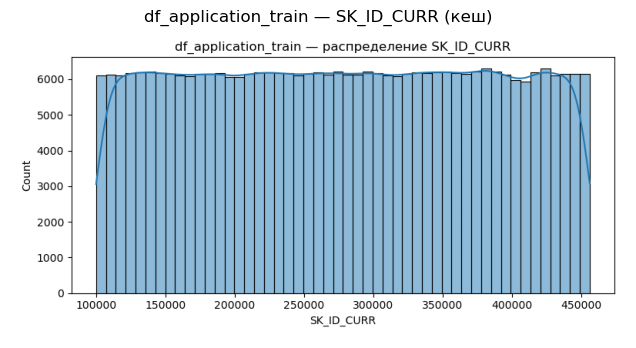

  → Numeric: df_application_train.TARGET


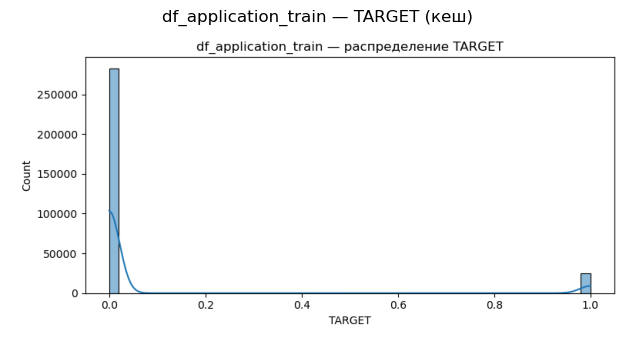

  → Categorical: df_application_train.NAME_CONTRACT_TYPE


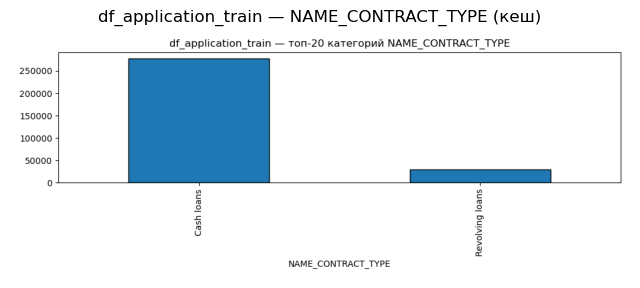

  → Categorical: df_application_train.CODE_GENDER


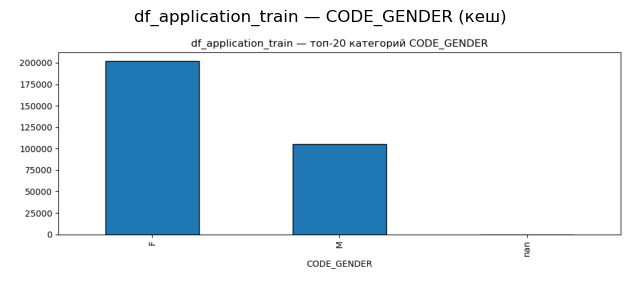

  → Categorical: df_application_train.FLAG_OWN_CAR


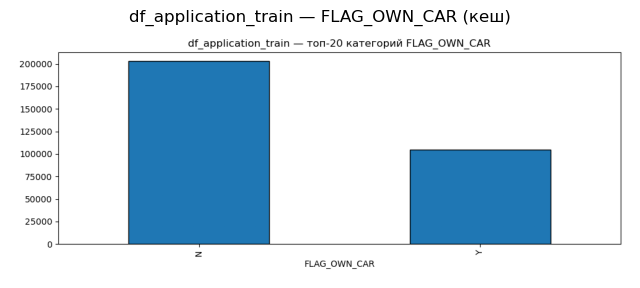

  → Categorical: df_application_train.FLAG_OWN_REALTY


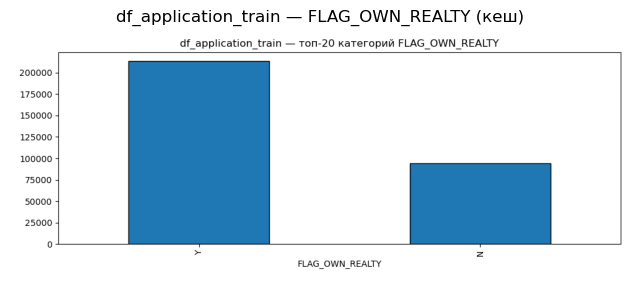

  → Numeric: df_application_train.CNT_CHILDREN


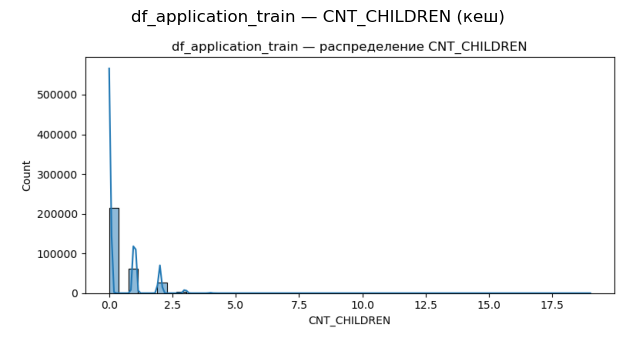

  → Numeric: df_application_train.AMT_CREDIT


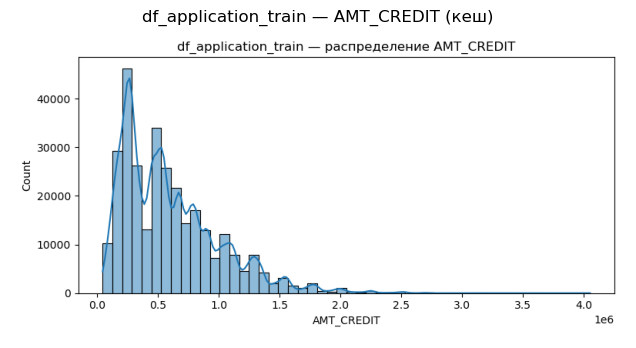

  → Numeric: df_application_train.AMT_ANNUITY


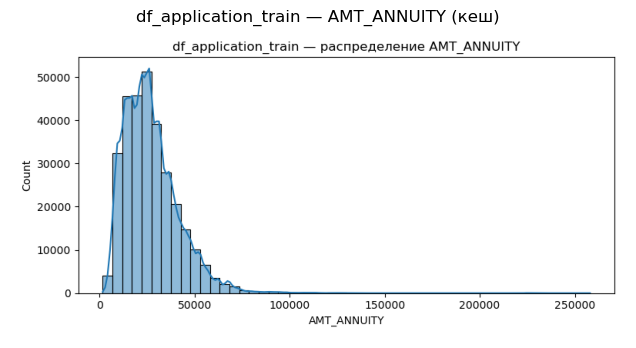

  → Numeric: df_application_train.AMT_GOODS_PRICE


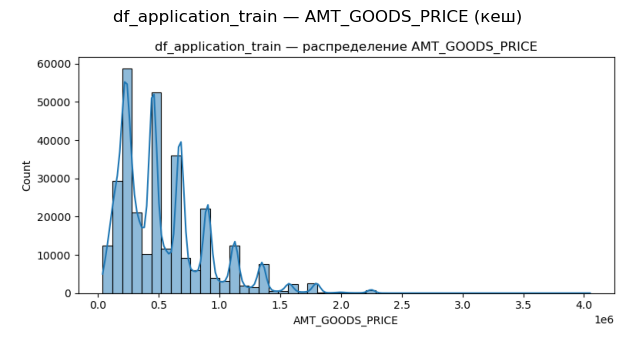

  → Categorical: df_application_train.NAME_TYPE_SUITE


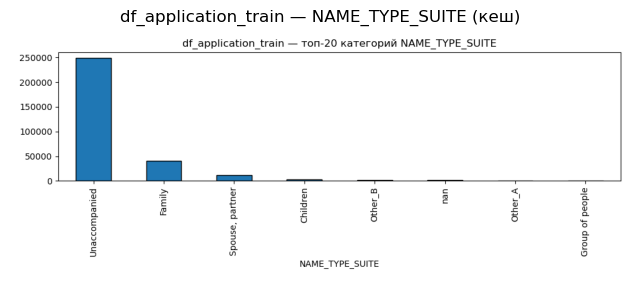

  → Categorical: df_application_train.NAME_INCOME_TYPE


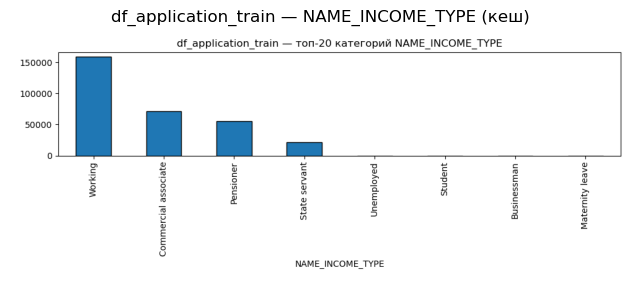

  → Categorical: df_application_train.NAME_EDUCATION_TYPE


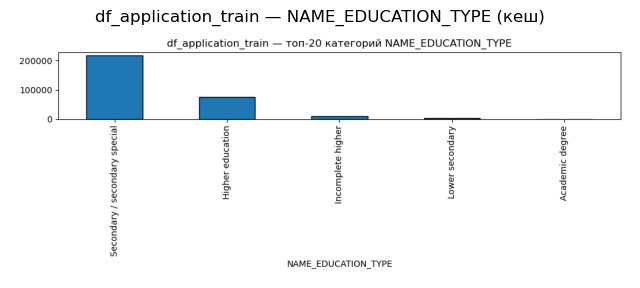

  → Categorical: df_application_train.NAME_FAMILY_STATUS


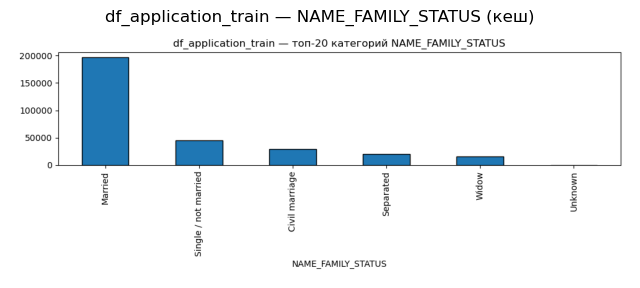

  → Categorical: df_application_train.NAME_HOUSING_TYPE


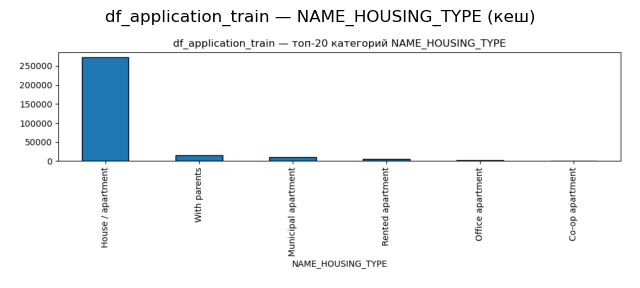

  → Numeric: df_application_train.REGION_POPULATION_RELATIVE


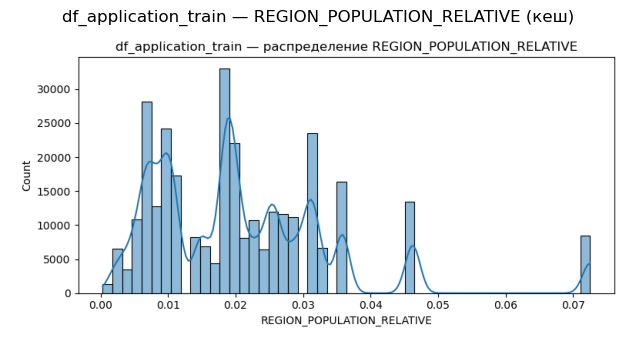

  → Numeric: df_application_train.DAYS_BIRTH


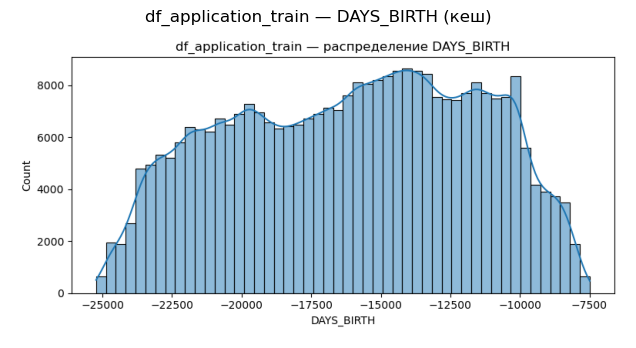

  → Numeric: df_application_train.DAYS_EMPLOYED


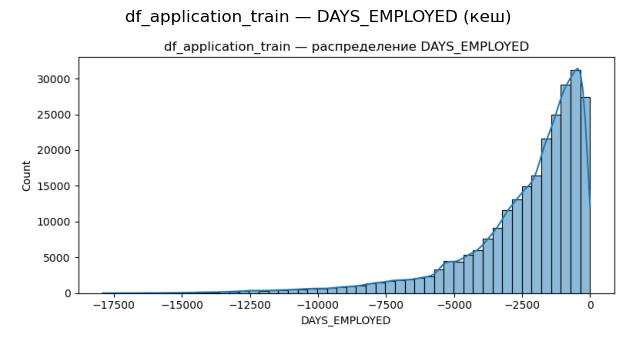

  → Categorical: df_application_train.OCCUPATION_TYPE


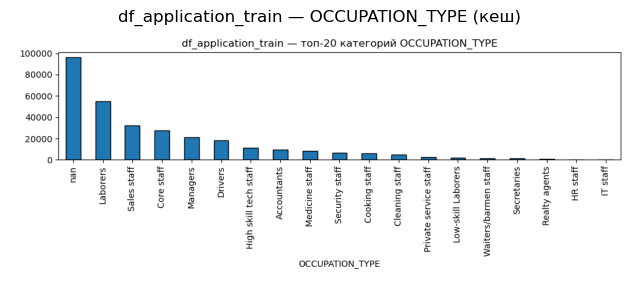


=== Строю графики для таблицы df_bureau ===
  → Numeric: df_bureau.SK_ID_CURR


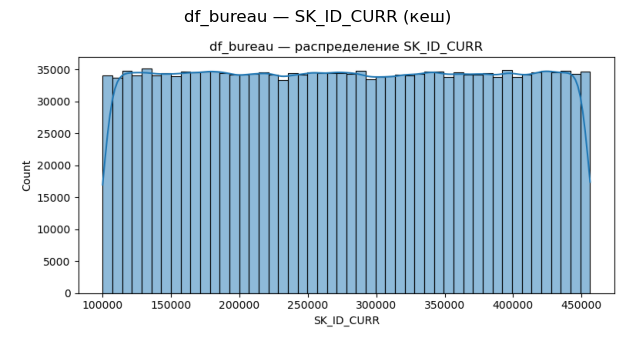

  → Numeric: df_bureau.SK_ID_BUREAU


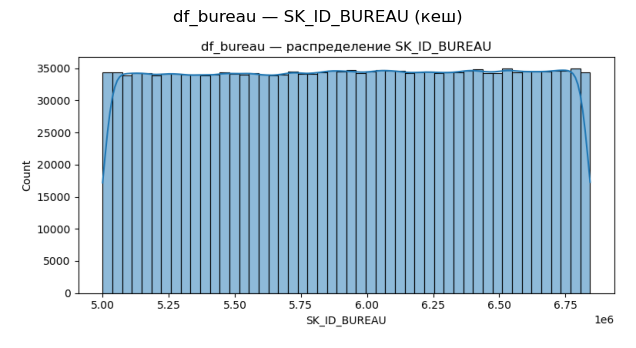

  → Categorical: df_bureau.CREDIT_ACTIVE


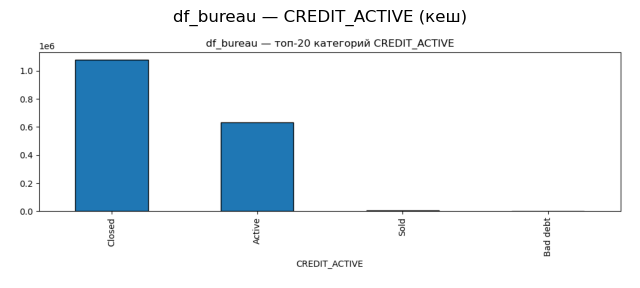

  → Numeric: df_bureau.DAYS_CREDIT


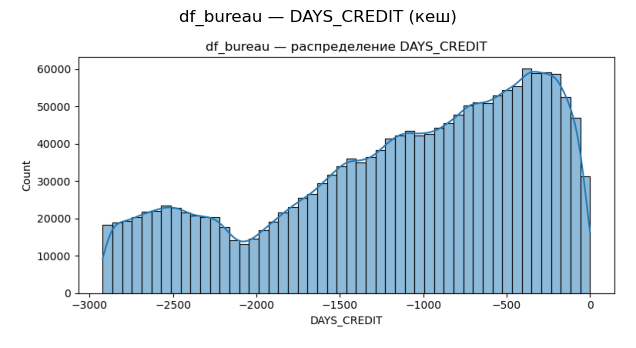

  → Numeric: df_bureau.DAYS_ENDDATE_FACT


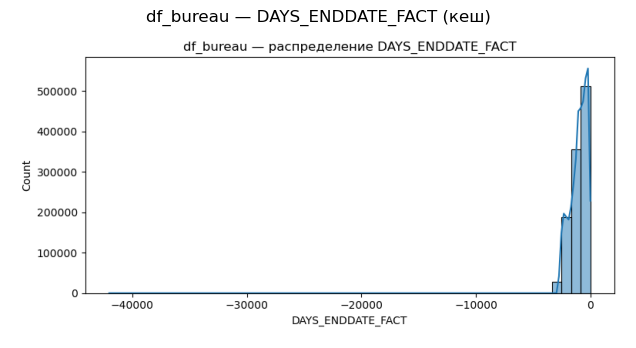

  → Categorical: df_bureau.CREDIT_TYPE


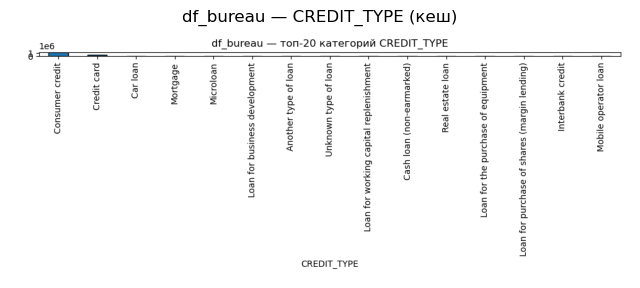


=== Строю графики для таблицы df_bureau_balance ===
  → Numeric: df_bureau_balance.SK_ID_BUREAU


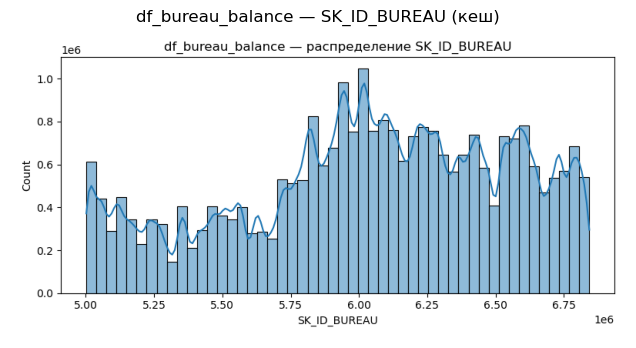

  → Categorical: df_bureau_balance.STATUS


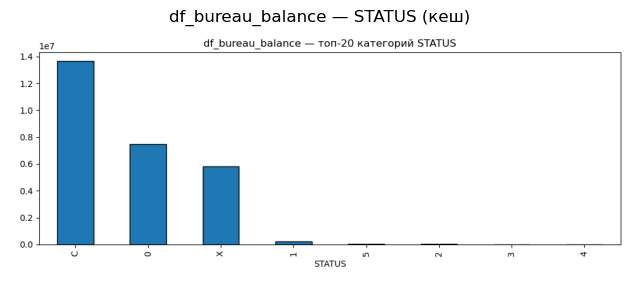


=== Строю графики для таблицы df_credit_card_balance ===
  → Numeric: df_credit_card_balance.SK_ID_PREV


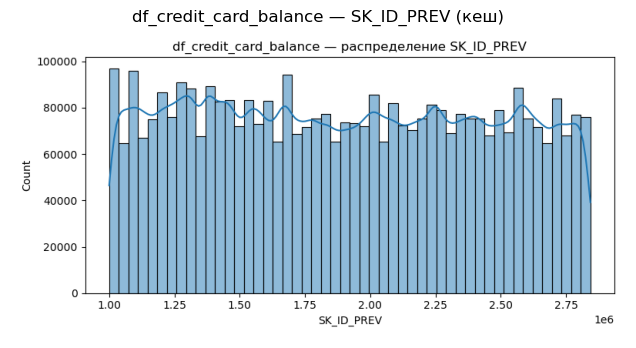

  → Numeric: df_credit_card_balance.SK_ID_CURR


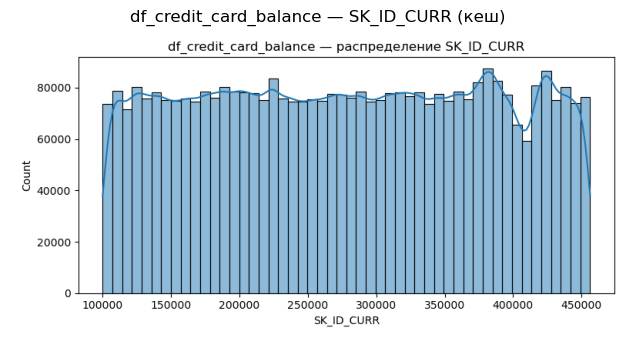

  → Numeric: df_credit_card_balance.AMT_BALANCE


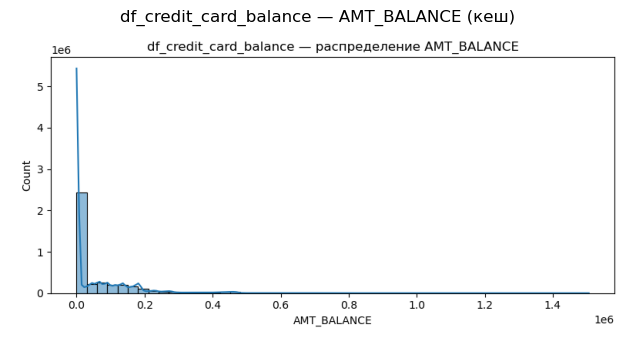

  → Numeric: df_credit_card_balance.AMT_CREDIT_LIMIT_ACTUAL


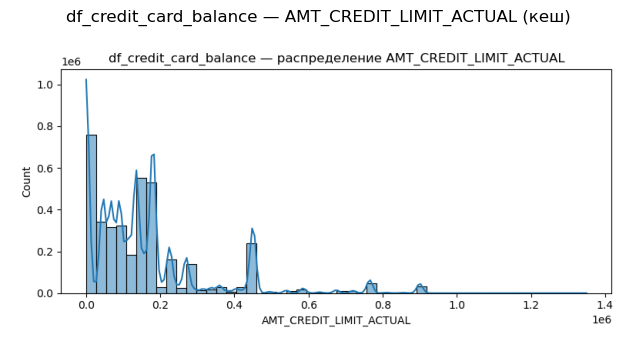

  → Numeric: df_credit_card_balance.AMT_DRAWINGS_ATM_CURRENT


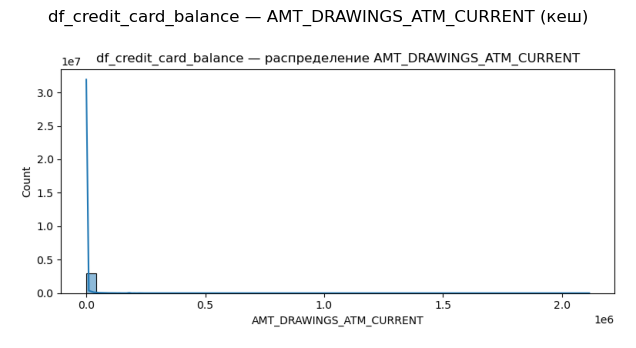

  → Numeric: df_credit_card_balance.AMT_INST_MIN_REGULARITY


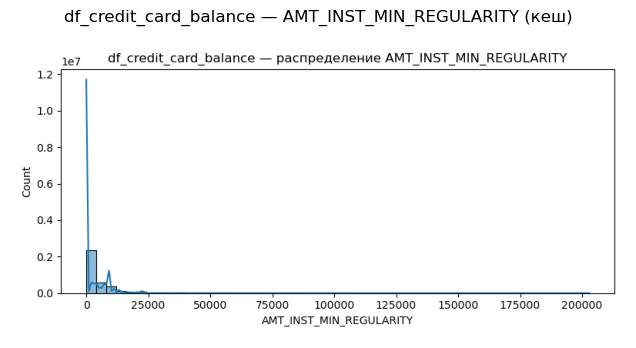


=== Строю графики для таблицы df_installments_payments ===
  → Numeric: df_installments_payments.SK_ID_PREV


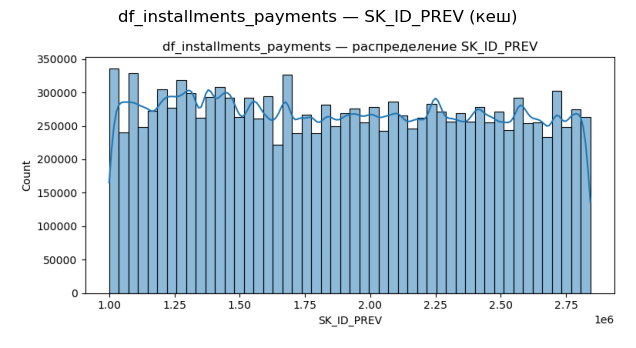

  → Numeric: df_installments_payments.SK_ID_CURR


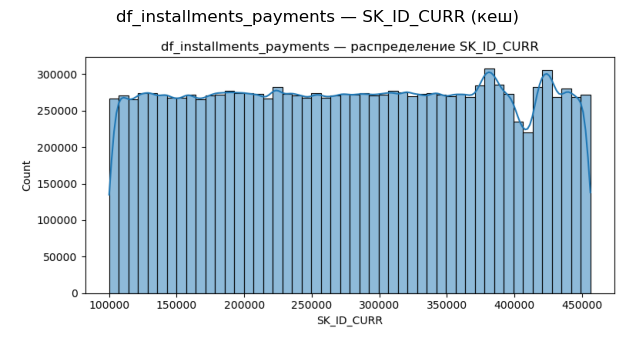

  → Numeric: df_installments_payments.NUM_INSTALMENT_VERSION


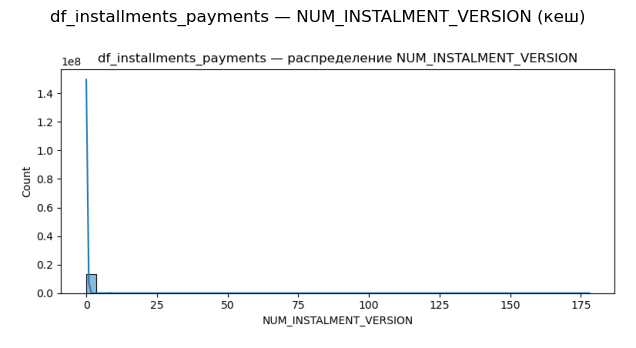

  → Numeric: df_installments_payments.NUM_INSTALMENT_NUMBER


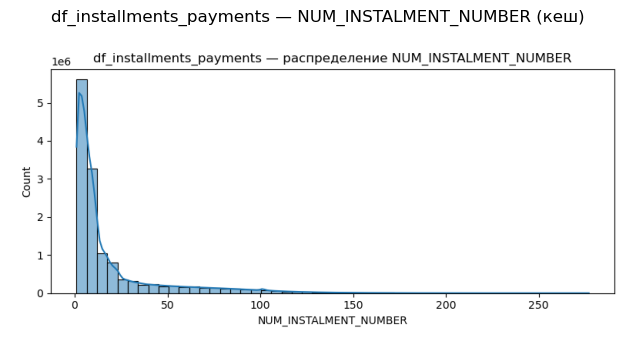

  → Numeric: df_installments_payments.DAYS_INSTALMENT


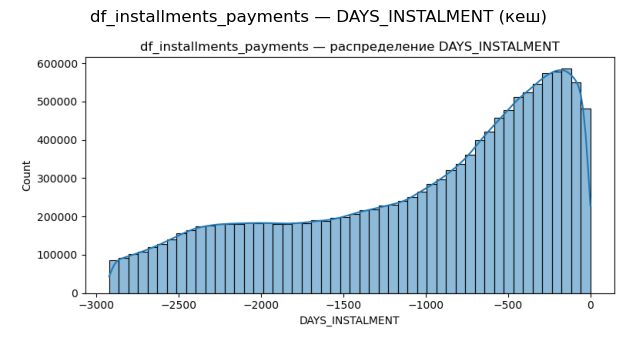

  → Numeric: df_installments_payments.DAYS_ENTRY_PAYMENT


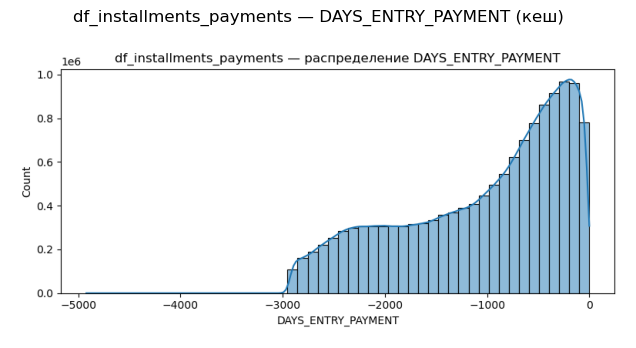


=== Строю графики для таблицы df_pos_cash_balance ===
  → Numeric: df_pos_cash_balance.SK_ID_PREV


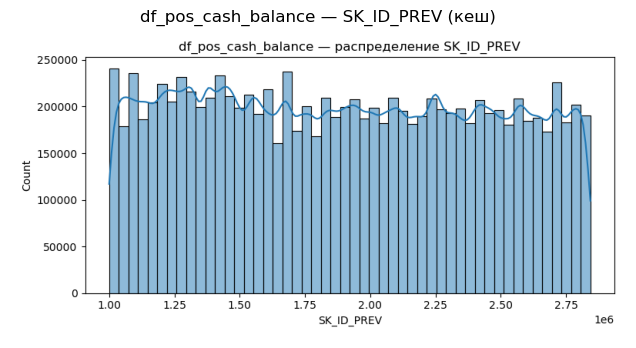

  → Numeric: df_pos_cash_balance.SK_ID_CURR


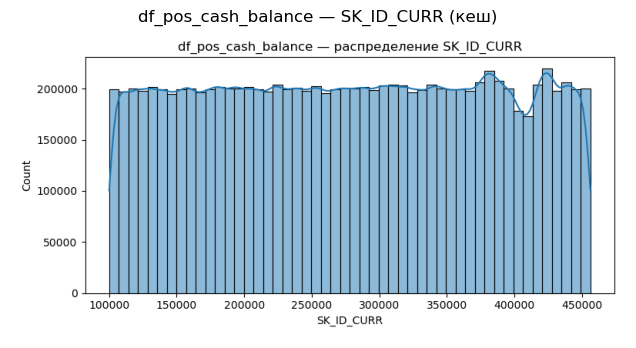

  → Numeric: df_pos_cash_balance.CNT_INSTALMENT


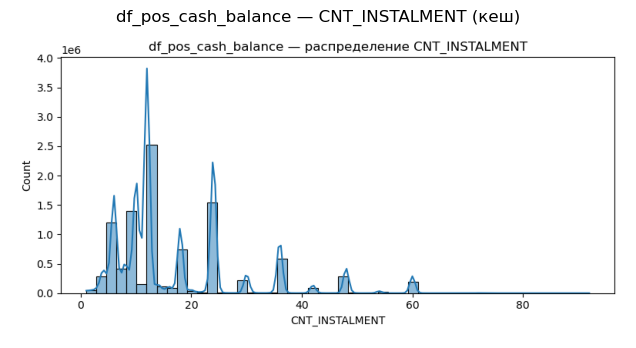

  → Numeric: df_pos_cash_balance.CNT_INSTALMENT_FUTURE


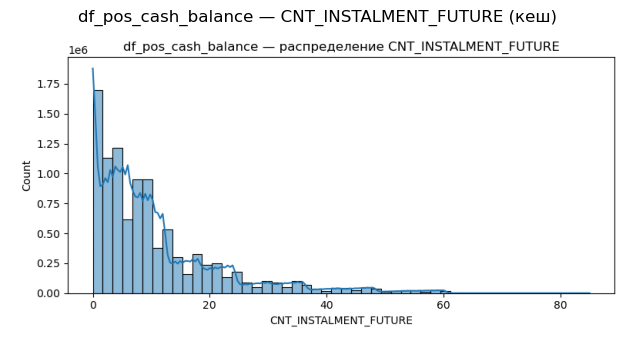

  → Categorical: df_pos_cash_balance.NAME_CONTRACT_STATUS


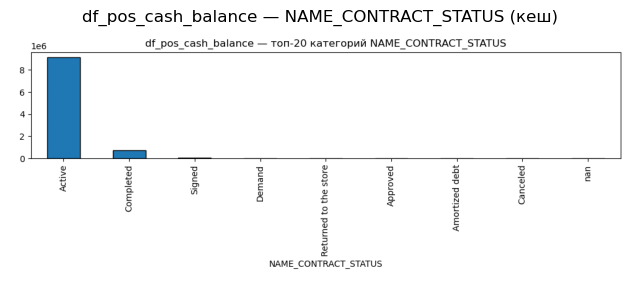


=== Строю графики для таблицы df_previous_application ===
  → Numeric: df_previous_application.SK_ID_PREV


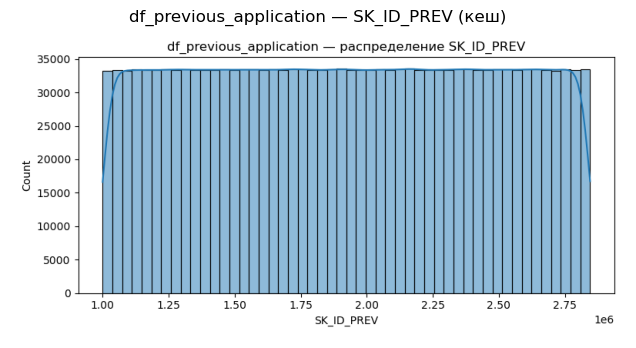

  → Numeric: df_previous_application.SK_ID_CURR


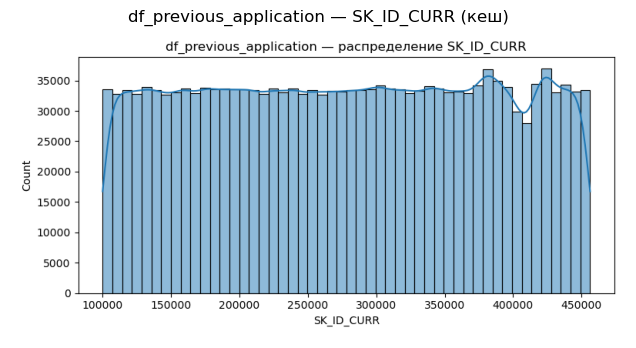

  → Categorical: df_previous_application.NAME_CONTRACT_TYPE


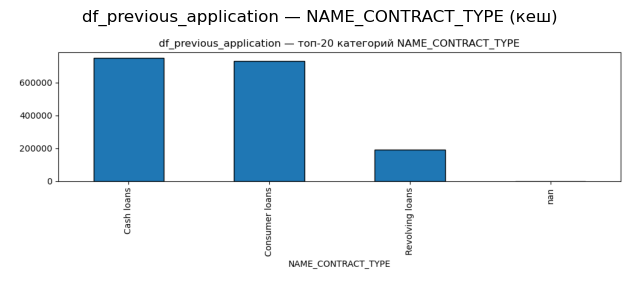

  → Numeric: df_previous_application.AMT_ANNUITY


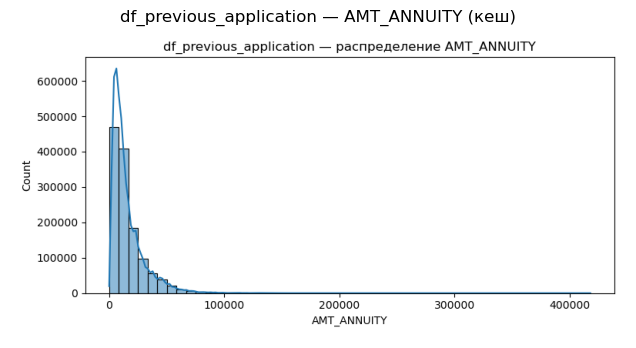

  → Numeric: df_previous_application.AMT_APPLICATION


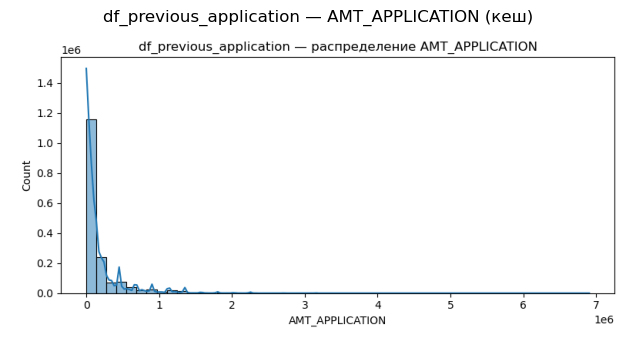

  → Numeric: df_previous_application.AMT_CREDIT


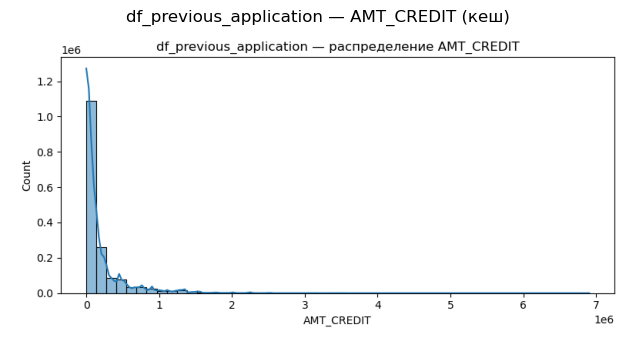

  → Numeric: df_previous_application.AMT_GOODS_PRICE


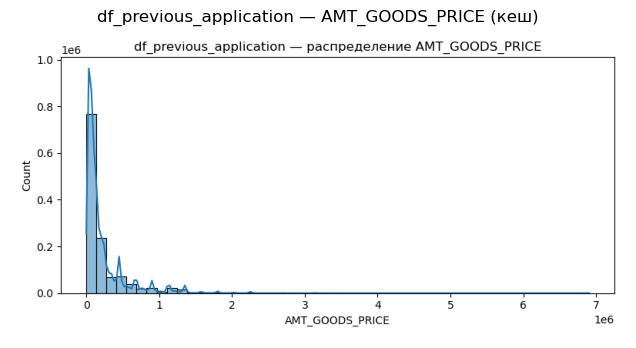

  → Categorical: df_previous_application.WEEKDAY_APPR_PROCESS_START


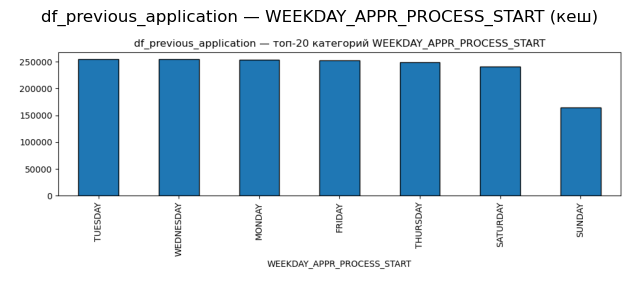

  → Numeric: df_previous_application.HOUR_APPR_PROCESS_START


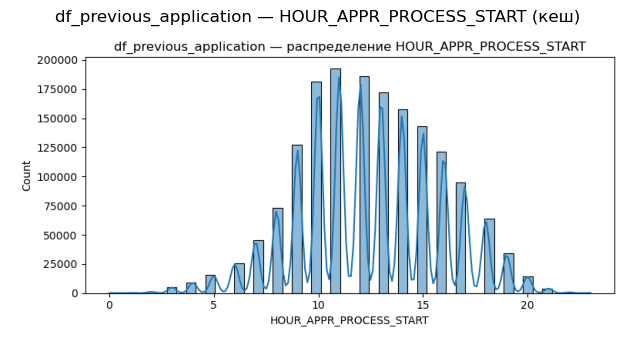

  → Categorical: df_previous_application.NAME_CASH_LOAN_PURPOSE


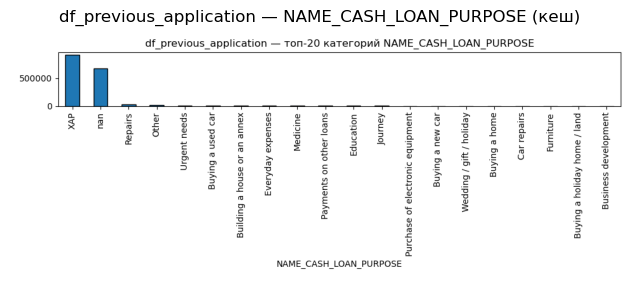

  → Categorical: df_previous_application.NAME_CONTRACT_STATUS


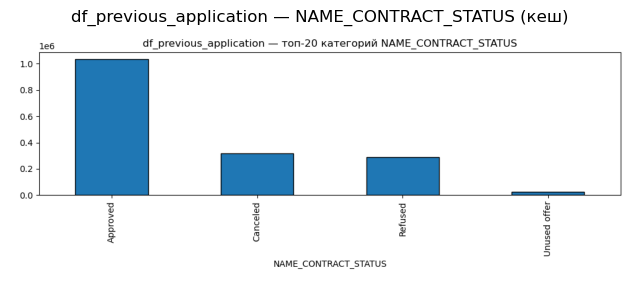

  → Categorical: df_previous_application.CODE_REJECT_REASON


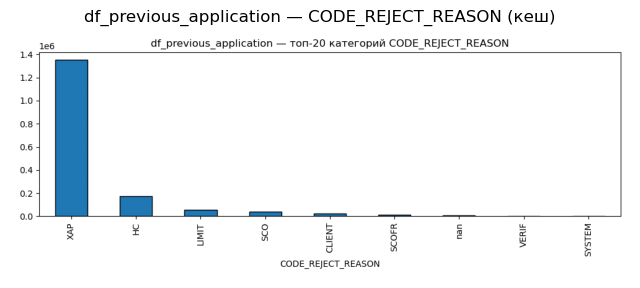

  → Categorical: df_previous_application.NAME_TYPE_SUITE


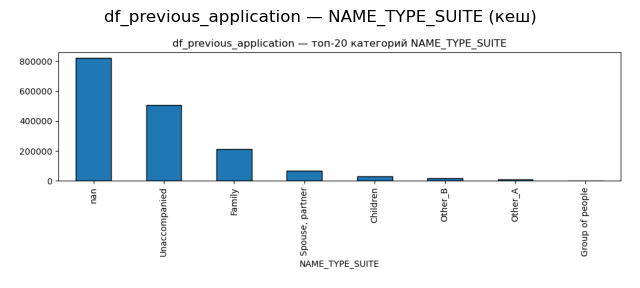

  → Categorical: df_previous_application.NAME_CLIENT_TYPE


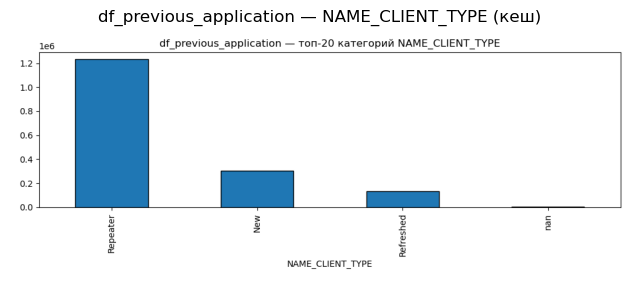


✔ Графики для перспективных признаков построены и сохранены.


In [45]:
# ---------------------------------------------------------
# Запуск функции построения графиков для перспективных признаков
# ---------------------------------------------------------

plot_promising_features(dfs_cleaned, promising_features, eda_config)

In [46]:
# ---------------------------------------------------------
# Сохранение результатов Stage 2 в динамический путь из конфигурации проекта
# ---------------------------------------------------------

# ---------------------------------------------------------
# Загружаем динамический путь для Stage 2
# ---------------------------------------------------------
with open("project_structure_config.json", "r", encoding="utf-8") as f:
    config = json.load(f)

stage2_output_path = config["stages"]["stage2"]["output_path"]
os.makedirs(stage2_output_path, exist_ok=True)

# ---------------------------------------------------------
# Сохраняем перспективные признаки
# ---------------------------------------------------------
with open(os.path.join(stage2_output_path, "promising_features.json"), "w", encoding="utf-8") as f:
    json.dump(promising_features, f, indent=4)

# ---------------------------------------------------------
# Сохраняем отчет об удалении признаков
# ---------------------------------------------------------
with open(os.path.join(stage2_output_path, "removal_report.json"), "w", encoding="utf-8") as f:
    json.dump(removal_report, f, indent=4)

print("Результаты Stage 2 сохранены:")
print(" - promising_features.json")
print(" - removal_report.json")

# ---------------------------------------------------------
# Сохраняем EDA словари
# ---------------------------------------------------------
save_eda_dictionaries()

Результаты Stage 2 сохранены:
 - promising_features.json
 - removal_report.json
✔ Сохранено: data/stage_outputs/stage2_eda/dicts\summary_dict.pkl
✔ Сохранено: data/stage_outputs/stage2_eda/dicts\numeric_stats_dict.pkl
✔ Сохранено: data/stage_outputs/stage2_eda/dicts\categorical_stats_dict.pkl
✔ Сохранено: data/stage_outputs/stage2_eda/dicts\quality_flags_dict.pkl
✔ Сохранено: data/stage_outputs/stage2_eda/dicts\correlation_dict.pkl
✔ Сохранено: data/stage_outputs/stage2_eda/dicts\plot_recommendations_dict.pkl
✔ Сохранено: data/stage_outputs/stage2_eda/dicts\table_specific_dict.pkl

✔ Все EDA‑словари сохранены в: data/stage_outputs/stage2_eda/dicts


In [47]:
# ---------------------------------------------------------
# Сохраняем краткую сводку по Stage 2 в JSON формате
# ---------------------------------------------------------

stage2_summary = {
    "tables": list(dfs_cleaned.keys()),
    "promising_feature_counts": {t: len(promising_features[t]) for t in promising_features},
    "removed_feature_counts": {t: len(removal_report[t]) for t in removal_report},
    "missing_threshold": eda_config["missing_threshold"],
    "cardinality_threshold": eda_config["cardinality_threshold"],
    "skew_threshold": eda_config["skew_threshold"],
    "timestamp": datetime.now().isoformat()
}

with open(os.path.join(stage2_output_path, "stage2_summary.json"), "w", encoding="utf-8") as f:
    json.dump(stage2_summary, f, indent=4)


In [48]:
# ---------------------------------------------------------
# Создаем талицу для моделирования, которая включает только перспективные признаки из application_train, и сохраняем
# её в формате Parquet в динамический путь Stage 2, чтобы обеспечить быстрый доступ к данным для последующего этапа моделирования.
# ---------------------------------------------------------

cols = promising_features["df_application_train"].copy()
if "TARGET" not in cols:
    cols.append("TARGET")

modeling_df = dfs_cleaned["df_application_train"][cols]

modeling_df.to_parquet(
    os.path.join(stage2_output_path, "modeling_table.parquet"),
    index=False
)



In [49]:
# ---------------------------------------------------------
# Выводим лог о завершении Stage 2 и сохраненных файлах
# ---------------------------------------------------------

print("\n=== Stage 2 завершина успешно ===")
print("Сохранены:")
print(" - EDA словари")
print(" - promising_features.json")
print(" - removal_report.json")
print(" - stage2_summary.json")
print(" - modeling_table.parquet")



=== Stage 2 завершина успешно ===
Сохранены:
 - EDA словари
 - promising_features.json
 - removal_report.json
 - stage2_summary.json
 - modeling_table.parquet


In [50]:
# ----------------------------------------------------------
# Сохраняем плоскую версию отчета об удалении признаков для удобного просмотра и анализа, которая будет содержать строки
# в формате "таблица.признак: причина удаления", и сохраняем её в JSON формате в динамический путь Stage 2 для быстрого
# доступа и использования при анализе данных и принятии решений по обработке данных.
# ----------------------------------------------------------

removed_flat = {
    f"{table}.{col}": reason
    for table, cols in removal_report.items()
    for col, reason in cols.items()
}

with open(os.path.join(stage2_output_path, "removed_features_flat.json"), "w", encoding="utf-8") as f:
    json.dump(removed_flat, f, indent=4)


# Stage 3 — Baseline LightGBM Model (`stage3_baseline`)

**Назначение этапа:**  
Построить базовую модель (Baseline) на основе перспективных признаков,  
выделенных в Stage 2, и подготовить модельную таблицу для последующих  
итераций улучшения качества. Этап служит отправной точкой для сравнения  
всех будущих моделей.

**Входные данные:**  
- Модельная таблица из Stage 2 (`modeling_table.parquet`)  
- Список перспективных признаков (`promising_features.json`)  
- Отчёт об удалённых признаках (`removal_report.json`)  
- Конфигурация проекта (`project_structure_config.json`)  
- **Путь к данным:** `data/stage_outputs/stage2_eda/`

**Выходные данные:**  
- Базовая модель LightGBM (`baseline_model.pkl`)  
- Метрики качества (ROC‑AUC, PR‑AUC, LogLoss)  
- Важности признаков (`feature_importance.csv`)  
- Предсказания на train/valid (`baseline_predictions.parquet`)  
- Итоговый отчёт Stage 3 (`stage3_summary.json`)  
- **Путь сохранения:** `data/stage_outputs/stage3_baseline/`

**Краткое описание обработки:**  
- Загрузка модельной таблицы и перспективных признаков  
- Разделение данных на train/valid (stratified split)  
- Обработка пропусков и категориальных признаков  
- Обучение базовой модели LightGBM  
- Оценка качества модели  
- Сохранение модели, метрик, предсказаний и отчёта Stage 3  
- Подготовка данных для Stage 4 (Feature Engineering / Hyperparameter Tuning)


In [60]:
# ---------------------------------------------------------
# Stage 3 единый загрузчик входных данных (memory-first, disk fallback)
# ---------------------------------------------------------


def load_stage3_inputs(modeling_df=None, promising_features=None):
    """
    Загружает входы Stage 3:
    - модельную таблицу
    - перспективные признаки
    - конфигурацию проекта

    Выполняет валидацию:
    - наличие TARGET
    - отсутствие пропавших признаков из списка promising_features

    """

    # ---------------------------------------------------------
    # Загружаем конфигурацию проекта
    # ---------------------------------------------------------
    with open("project_structure_config.json", "r", encoding="utf-8") as f:
        config = json.load(f)

    stage2_path = config["stages"]["stage2"]["output_path"]

    # ---------------------------------------------------------
    # 1. Загружаем таблицу MODELING TABLE
    # ---------------------------------------------------------
    if modeling_df is not None:
        print("✔ Modeling table already in memory — using existing object.")
    else:
        modeling_path = os.path.join(stage2_path, "modeling_table.parquet")
        if not os.path.exists(modeling_path):
            raise FileNotFoundError(f"Modeling table not found: {modeling_path}")

        print(f"Загружаем таблицу MODELING TABLE из: {modeling_path}")
        modeling_df = pd.read_parquet(modeling_path)

    # ---------------------------------------------------------
    # 2. Загружаем перспективные признаки (PROMISING FEATURES)
    # ---------------------------------------------------------
    if promising_features is not None:
        print("✔ Promising features already in memory — using existing object.")
    else:
        promising_path = os.path.join(stage2_path, "promising_features.json")
        if not os.path.exists(promising_path):
            raise FileNotFoundError(f"Файл перспективных признаков не найден: {promising_path}")

        print(f"Загружаем перспективные признаки из: {promising_path}")
        with open(promising_path, "r", encoding="utf-8") as f:
            promising_features = json.load(f)

    # ---------------------------------------------------------
    # 3. Валидация TARGET
    # ---------------------------------------------------------
    if "TARGET" not in modeling_df.columns:
        raise ValueError("Столбец TARGET отсутствует в таблице моделирования.")

    # ---------------------------------------------------------
    # 4. Валидация отсутствия пропавших признаков
    # ---------------------------------------------------------
    expected_cols = set(promising_features["df_application_train"]) | {"TARGET"}
    actual_cols = set(modeling_df.columns)

    missing_cols = expected_cols - actual_cols

    if missing_cols:
        raise ValueError(
            f"Отсутствующие столбцы в таблице моделирования: {sorted(missing_cols)}\n"
            "Это указывает на несоответствие между Stage 2 и Stage 3."
        )

    print("✔ Все необходимые столбцы присутствуют.")
    print("✔ Входные данные Stage 3 успешно загружены.")

    return modeling_df, promising_features, config



In [61]:
# ---------------------------------------------------------
# Запуск загрузчика входных данных для Stage 3
# ---------------------------------------------------------

modeling_df, promising_features, config = load_stage3_inputs()


Загружаем таблицу MODELING TABLE из: data/stage_outputs/stage2_eda/modeling_table.parquet
Загружаем перспективные признаки из: data/stage_outputs/stage2_eda/promising_features.json
✔ Все необходимые столбцы присутствуют.
✔ Входные данные Stage 3 успешно загружены.
